# MetaLore — Per-Profile Simulation & Grid Search

Each profile section has four cells:
1. **Simulation** — animated rendering with `[0.5, 0.5]`
2. **Summary** — active UEs, cumulative reward, throughput
3. **Grid search (run)** — 9×9 bw/comp splits × 10 seeds, stores results in `summ`
4. **Grid search (results)** — heatmaps + best splits table

Run **Setup** first, then each profile's cells in order.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv
from metalore.config import default_config
from metalore.core.arrival.dynamic import DynamicArrival

COLORS = {
    'low':       '#4e79a7',
    'medium':    '#f28e2b',
    'high':      '#e15759',
    'ramp_up':   '#76b7b2',
    'ramp_down': '#59a14f',
    'burst':     '#b07aa1',
}

T           = default_config()['environment']['max_steps']
GRID_SPLITS = np.round(np.arange(0.1, 1.0, 0.1), 1)   # 0.1 … 0.9
N_GRID_RUNS = 10                                     # seeds per combination

print('T =', T)
print('Pool sizes:', DynamicArrival.POOL_SIZE)
print(f'Grid: {len(GRID_SPLITS)}x{len(GRID_SPLITS)} splits x {N_GRID_RUNS} seeds = {len(GRID_SPLITS)**2 * N_GRID_RUNS} episodes per profile')

class FixedProfileArrival(DynamicArrival):
    def __init__(self, profile, **kwargs):
        super().__init__(**kwargs)
        self._forced = profile
    def reset(self):
        super().reset()
        self.current_profile = self._forced

# ── Per-profile job parameters — edit here to customise each traffic type ──
JOB_DATA_SIZE = {
    'low':         300_000,   # 300 Kbits
    'medium':      500_000,   # 500 Kbits
    'high':        500_000,   # 500 Kbits
    'ramp_up':   1_000_000,   # 1 Mbit
    'ramp_down':   600_000,   # 600 Kbits
    'burst':       300_000,   # 300 Kbits
}

JOB_COMPUTE_SIZE = {
    'low':        50_000_000,   #  50 Mcycles
    'medium':    100_000_000,   # 100 Mcycles
    'high':      200_000_000,   # 200 Mcycles
    'ramp_up':    80_000_000,   #  80 Mcycles
    'ramp_down': 120_000_000,   # 120 Mcycles
    'burst':     250_000_000,   # 250 Mcycles
}

JOB_GEN_PROB = {
    'low':       0.5,
    'medium':    0.7,
    'high':      0.9,
    'ramp_up':   0.7,
    'ramp_down': 0.8,
    'burst':     0.8,
}

def make_env(profile, seed=42):
    cfg = default_config()
    cfg['environment']['seed']              = seed
    cfg['environment']['reset_rng_episode'] = True
    cfg['environment']['num_ues']           = DynamicArrival.POOL_SIZE[profile]
    cfg['job_ue']['data_size_mean']         = JOB_DATA_SIZE[profile]
    cfg['job_ue']['compute_size_mean']      = JOB_COMPUTE_SIZE[profile]
    cfg['job_ue']['generation_probability'] = JOB_GEN_PROB[profile]
    class _A(FixedProfileArrival):
        def __init__(self, **kw):
            super().__init__(profile=profile, **kw)
    cfg['environment']['arrival_ue'] = _A
    return SingleCellEnv(config=cfg)

def draw_heatmap(ax, summ, col, title, cmap, best_fn, label):
    data     = summ.pivot(index='comp_split', columns='bw_split', values=col).iloc[::-1]
    vals     = data.values.astype(float)
    valid    = summ[col].dropna()
    if valid.empty:
        ax.set_title(f'{label}\n{title} — N/A', fontsize=9)
        return
    best_val = best_fn(valid)
    im = ax.imshow(vals, cmap=cmap, aspect='auto',
                   vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(data.columns)))
    ax.set_yticks(range(len(data.index)))
    ax.set_xticklabels([f'{v:.1f}' for v in data.columns], fontsize=8)
    ax.set_yticklabels([f'{v:.1f}' for v in data.index], fontsize=8)
    ax.set_xlabel('bw_split', fontsize=9)
    ax.set_ylabel('comp_split', fontsize=9)
    ax.set_title(f'{label}\n{title}', fontsize=10, fontweight='bold')
    norm = mcolors.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isnan(v): continue
            color   = 'white' if norm(v) > 0.55 else 'black'
            is_best = np.isclose(v, best_val)
            ax.text(j, i, f'{v:.2f}{"★" if is_best else ""}',
                    ha='center', va='center', fontsize=7,
                    color=color, fontweight='bold' if is_best else 'normal')

T = 100
Pool sizes: {'low': 20, 'medium': 30, 'high': 40, 'ramp_up': 30, 'ramp_down': 30, 'burst': 30}
Grid: 9x9 splits x 10 seeds = 810 episodes per profile


---
## Profile: `low`

Sparse cell. Pool size from `DynamicArrival.POOL_SIZE["low"]`.

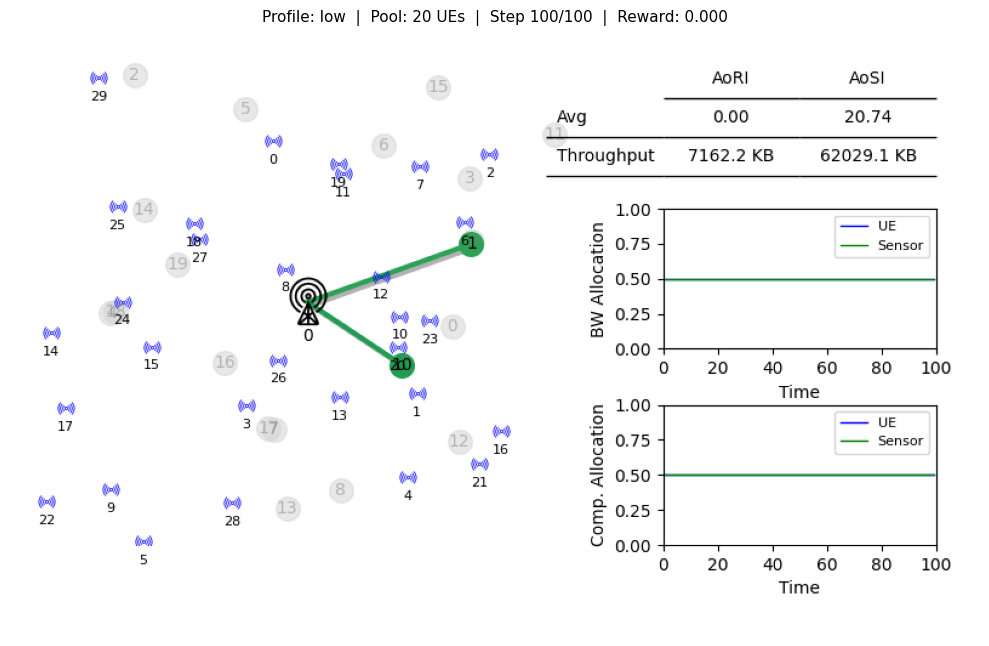

Episode complete — 100 steps  |   Total reward: 320.21


In [27]:
profile = 'low'
n_ues  = DynamicArrival.POOL_SIZE[profile]
color  = COLORS[profile]
env    = make_env(profile)
obs, _ = env.reset()

rewards, active_ues = [], []
done = False

while not done:
    obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
    rewards.append(reward)
    active_ues.append(env.metrics.latest('num_active_ues'))
    done = terminated or truncated

    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Profile: {profile}  |  Pool: {n_ues} UEs  |  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
        fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

job_df = env.job_tracker.to_dataframe()
ue_df  = job_df[job_df['entity_type'] == 'UE']
ep     = env.metrics.finalize(env.job_tracker)
env.close()
print(f'Episode complete — {len(rewards)} steps  |   Total reward: {sum(rewards):.2f}')

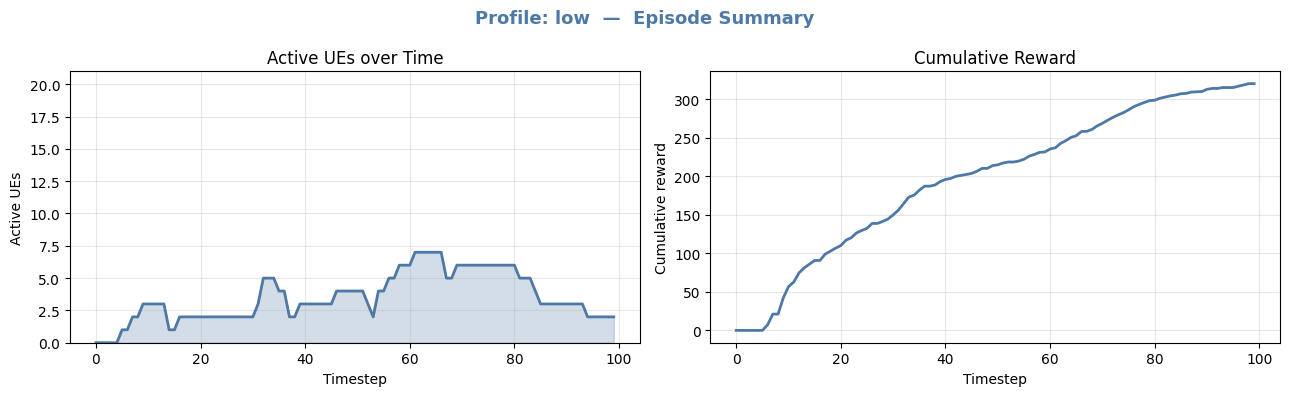

Pool            : 20 UEs
Total reward    : 320.21
UE jobs done    : 191
UE throughput   : 7.162 MB
Mean AoRI       : 0.000 steps
Mean AoSI       : 20.743 steps
Completion rate : 0.682
Timely rate     : 1.000
Residual jobs   : 0.000


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Profile: {profile}  —  Episode Summary',
             fontsize=13, fontweight='bold', color=color)

ax1.fill_between(range(len(active_ues)), active_ues, alpha=0.25, color=color)
ax1.plot(active_ues, color=color, lw=2)
ax1.set_title('Active UEs over Time')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Active UEs')
ax1.set_ylim(0, n_ues + 1)
ax1.grid(True, alpha=0.3)

ax2.plot(np.cumsum(rewards), color=color, lw=2)
ax2.set_title('Cumulative Reward')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cumulative reward')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

throughput_mb = ue_df['data_size'].sum() / 8e6
print(f'Pool            : {n_ues} UEs')
print(f'Total reward    : {sum(rewards):.2f}')
print(f'UE jobs done    : {len(ue_df)}')
print(f'UE throughput   : {throughput_mb:.3f} MB')
print(f'Mean AoRI       : {ep.get("mean_aori", float("nan")):.3f} steps')
print(f'Mean AoSI       : {ep.get("mean_aosi", float("nan")):.3f} steps')
print(f'Completion rate : {ep.get("job_completion_rate", float("nan")):.3f}')
print(f'Timely rate     : {ep.get("timely_completion_rate", float("nan")):.3f}')
print(f'Residual jobs   : {ep.get("mean_residual_jobs_at_departure", float("nan")):.3f}')

In [4]:
# ── Exhaustive grid search: 81 combinations x N_GRID_RUNS seeds ───────────
records = []
total   = len(GRID_SPLITS) ** 2

env = make_env(profile)   # single env, reset per run

for idx, (bw_val, comp_val) in enumerate(itertools.product(GRID_SPLITS, GRID_SPLITS), start=1):
    run_aori, run_aosi, run_jobs, run_tput = [], [], [], []

    for run in range(N_GRID_RUNS):
        obs, _ = env.reset(seed=run)
        done = False

        while not done:
            obs, r, terminated, truncated, info = env.step([bw_val, comp_val])
            done = terminated or truncated

        ep  = env.metrics.finalize(env.job_tracker)
        jdf = env.job_tracker.to_dataframe()
        udf = jdf[jdf['entity_type'] == 'UE']

        if len(udf) > 0:
            mean_aori        = udf['aori'].mean()
            mean_aosi        = udf['aosi'].mean()
            jobs_done        = len(udf)
            ue_throughput_kb = udf['data_size'].sum() / 8000
        else:
            mean_aori = mean_aosi = np.nan
            jobs_done = 0
            ue_throughput_kb = 0.0

        records.append({
            'bw_split':                bw_val,
            'comp_split':              comp_val,
            'run':                     run,
            'mean_aori':               mean_aori,
            'mean_aosi':               mean_aosi,
            'jobs_done':               jobs_done,
            'ue_throughput_kb':        ue_throughput_kb,
            'completion_rate':         ep.get('job_completion_rate', 0),
            'timely_rate':             ep.get('timely_completion_rate'),
            'residual_jobs':           ep.get('mean_residual_jobs_at_departure'),
            'mean_ue_proc_queue':      ep.get('mean_ue_proc_queue'),
            'peak_ue_proc_queue':      ep.get('peak_ue_proc_queue'),
            'final_ue_proc_queue':     ep.get('final_ue_proc_queue'),
            'mean_sensor_proc_queue':  ep.get('mean_sensor_proc_queue'),
            'peak_sensor_proc_queue':  ep.get('peak_sensor_proc_queue'),
            'final_sensor_proc_queue': ep.get('final_sensor_proc_queue'),
        })
        run_aori.append(mean_aori)
        run_aosi.append(mean_aosi)
        run_jobs.append(jobs_done)
        run_tput.append(ue_throughput_kb)

    print(
        f'  [{idx:>2}/{total}]  bw={bw_val:.1f}  comp={comp_val:.1f}'
        f'  |  AoRI={np.nanmean(run_aori):6.2f}'
        f'  AoSI={np.nanmean(run_aosi):6.2f}'
        f'  jobs={int(np.nanmean(run_jobs))}'
        f'  tput={np.nanmean(run_tput):.0f} KB'
    )

env.close()

  [ 1/81]  bw=0.1  comp=0.1  |  AoRI=  1.27  AoSI=  1.02  jobs=181  tput=6787 KB
  [ 2/81]  bw=0.1  comp=0.2  |  AoRI=  1.18  AoSI=  0.93  jobs=181  tput=6787 KB
  [ 3/81]  bw=0.1  comp=0.3  |  AoRI=  1.18  AoSI=  3.57  jobs=181  tput=6787 KB
  [ 4/81]  bw=0.1  comp=0.4  |  AoRI=  1.18  AoSI= 11.30  jobs=181  tput=6787 KB
  [ 5/81]  bw=0.1  comp=0.5  |  AoRI=  1.18  AoSI= 18.93  jobs=181  tput=6787 KB
  [ 6/81]  bw=0.1  comp=0.6  |  AoRI=  1.18  AoSI= 26.62  jobs=181  tput=6787 KB
  [ 7/81]  bw=0.1  comp=0.7  |  AoRI=  1.18  AoSI= 34.30  jobs=181  tput=6787 KB
  [ 8/81]  bw=0.1  comp=0.8  |  AoRI=  1.18  AoSI= 41.94  jobs=181  tput=6787 KB
  [ 9/81]  bw=0.1  comp=0.9  |  AoRI=  1.18  AoSI= 49.59  jobs=181  tput=6787 KB
  [10/81]  bw=0.2  comp=0.1  |  AoRI=  0.23  AoSI=  1.19  jobs=191  tput=7162 KB
  [11/81]  bw=0.2  comp=0.2  |  AoRI=  0.07  AoSI=  1.32  jobs=191  tput=7162 KB
  [12/81]  bw=0.2  comp=0.3  |  AoRI=  0.07  AoSI=  4.70  jobs=191  tput=7162 KB
  [13/81]  bw=0.2  comp=0.4 

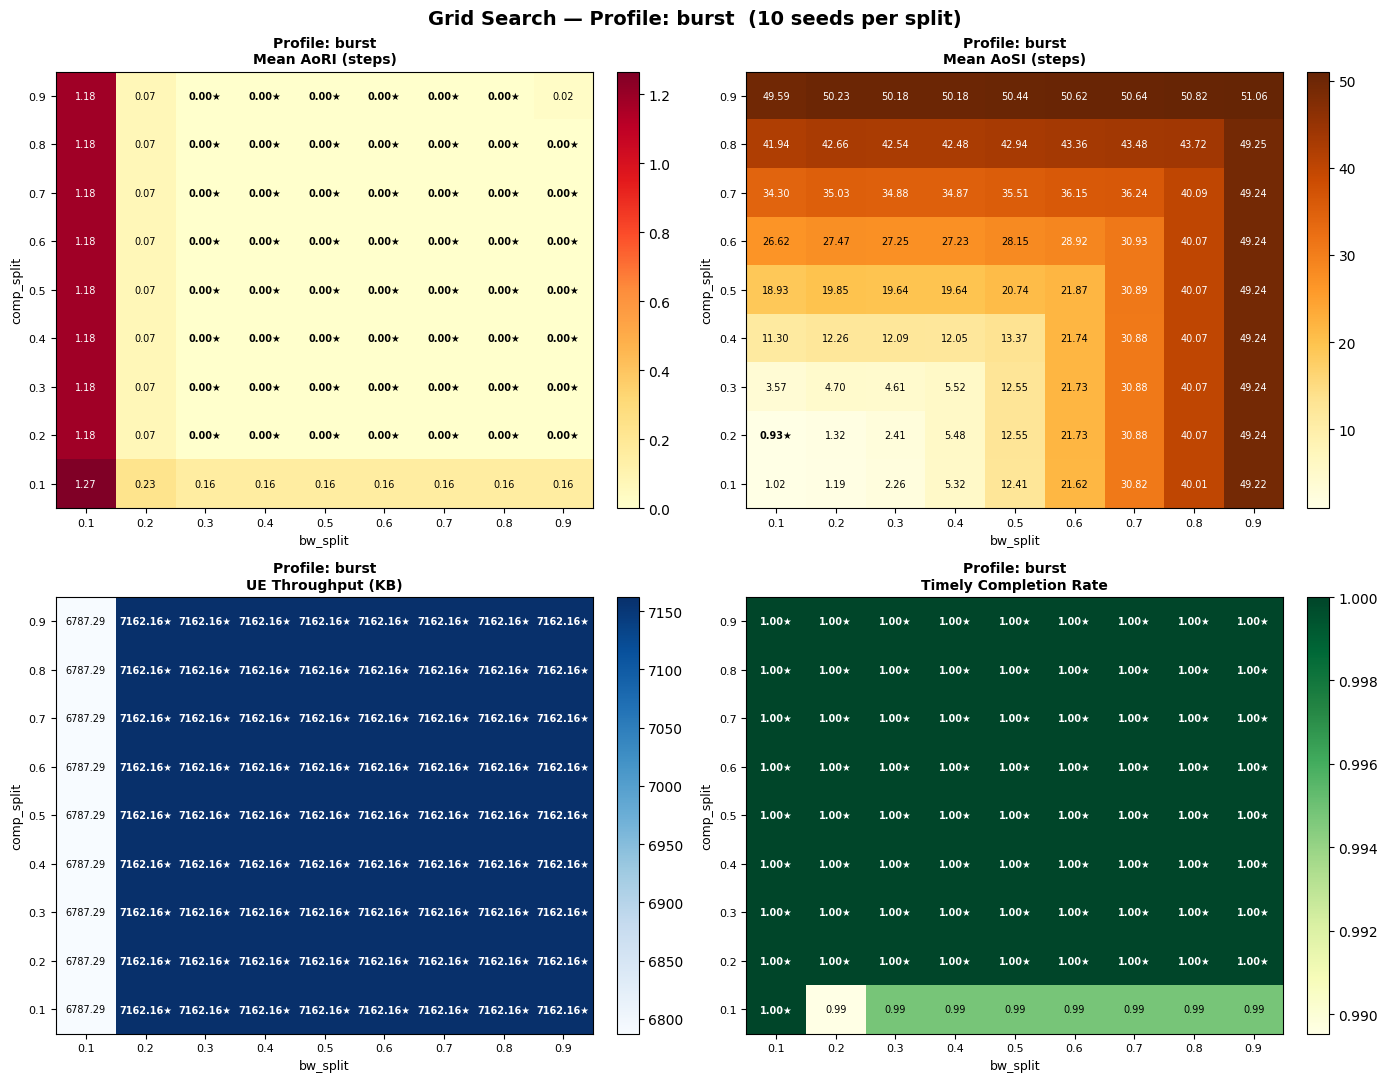

Best splits per metric:
Metric                          bw_split  comp_split       value
-----------------------------------------------------------------
Mean AoRI (steps)                    0.3         0.2       0.000
Mean AoSI (steps)                    0.1         0.2       0.928
UE Throughput (KB)                   0.2         0.1    7162.157
Completion Rate                      0.1         0.1       0.997
Timely Completion Rate               0.1         0.1       1.000
Residual Jobs at Departure           0.1         0.1       0.000


In [5]:
# ── Aggregate ─────────────────────────────────────────────────────────────
raw_df = pd.DataFrame(records)
summ = (
    raw_df.groupby(['bw_split', 'comp_split'])
    .agg(
        mean_aosi          =('mean_aosi',        'mean'),
        mean_aori          =('mean_aori',        'mean'),
        mean_throughput_kb =('ue_throughput_kb', 'mean'),
        mean_completion    =('completion_rate',  'mean'),
        mean_timely        =('timely_rate',      'mean'),
        mean_residual      =('residual_jobs',    'mean'),
    )
    .reset_index()
)

# ── Heatmaps (2x2): AoRI · AoSI · Throughput · Timely Completion Rate ───
HEATMAP_METRICS = [
    ('mean_aori',          'Mean AoRI (steps)',       'YlOrRd', np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',       'YlOrBr', np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',      'Blues',  np.nanmax),
    ('mean_timely',        'Timely Completion Rate',  'YlGn',   np.nanmax),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Grid Search — Profile: burst  (10 seeds per split)',
             fontsize=14, fontweight='bold')

for ax, (col, title, cmap, best_fn) in zip(axes.flat, HEATMAP_METRICS):
    draw_heatmap(ax, summ, col, title, cmap, best_fn, 'Profile: burst')

plt.tight_layout()
plt.show()

# ── All 6 metrics — best splits summary ──────────────────────────────────
print('Best splits per metric:')
print(f'{"Metric":<30s}  {"bw_split":>8s}  {"comp_split":>10s}  {"value":>10s}')
print('-' * 65)
for col, label, best_fn in [
    ('mean_aori',          'Mean AoRI (steps)',          np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',          np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',         np.nanmax),
    ('mean_completion',    'Completion Rate',            np.nanmax),
    ('mean_timely',        'Timely Completion Rate',     np.nanmax),
    ('mean_residual',      'Residual Jobs at Departure', np.nanmin),
]:
    valid = summ[col].dropna()
    if valid.empty:
        print(label.ljust(30) + '  ' + 'N/A')
        continue
    best_val = best_fn(valid)
    row = summ[np.isclose(summ[col], best_val)].iloc[0]
    print(f'{label:<30s}  {row.bw_split:>8.1f}  {row.comp_split:>10.1f}  {best_val:>10.3f}')

---
## Profile: `medium`

Moderate cell. Pool size from `DynamicArrival.POOL_SIZE["medium"]`.

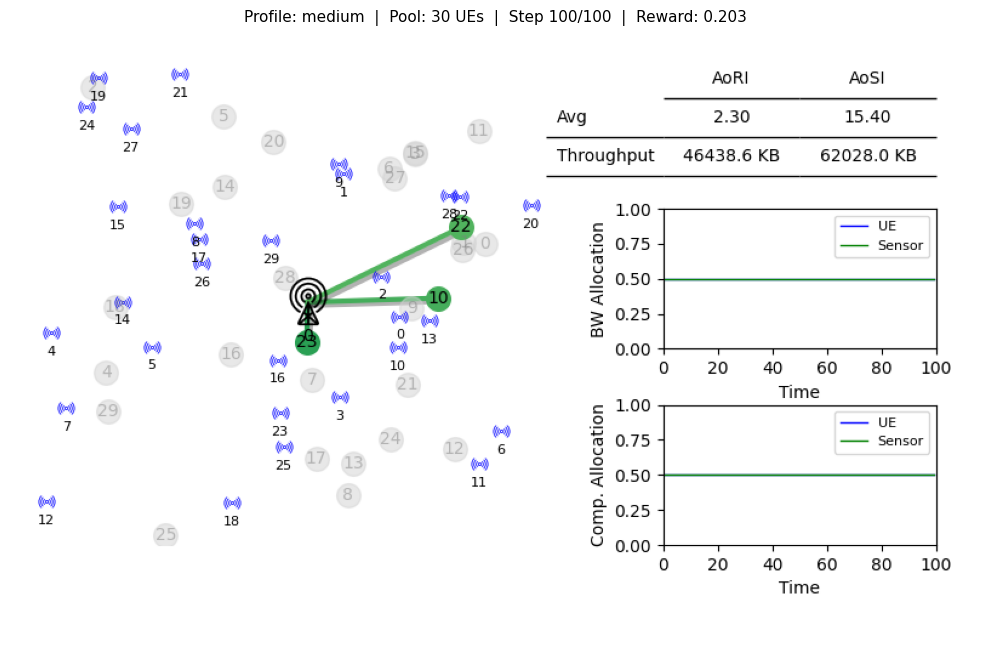

Episode complete — 100 steps  |   Total reward: 1828.15


In [6]:
profile = 'medium'
n_ues  = DynamicArrival.POOL_SIZE[profile]
color  = COLORS[profile]
env    = make_env(profile)
obs, _ = env.reset()

rewards, active_ues = [], []
done = False

while not done:
    obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
    rewards.append(reward)
    active_ues.append(env.metrics.latest('num_active_ues'))
    done = terminated or truncated

    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Profile: {profile}  |  Pool: {n_ues} UEs  |  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
        fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

job_df = env.job_tracker.to_dataframe()
ue_df  = job_df[job_df['entity_type'] == 'UE']
ep     = env.metrics.finalize(env.job_tracker)
env.close()
print(f'Episode complete — {len(rewards)} steps  |   Total reward: {sum(rewards):.2f}')

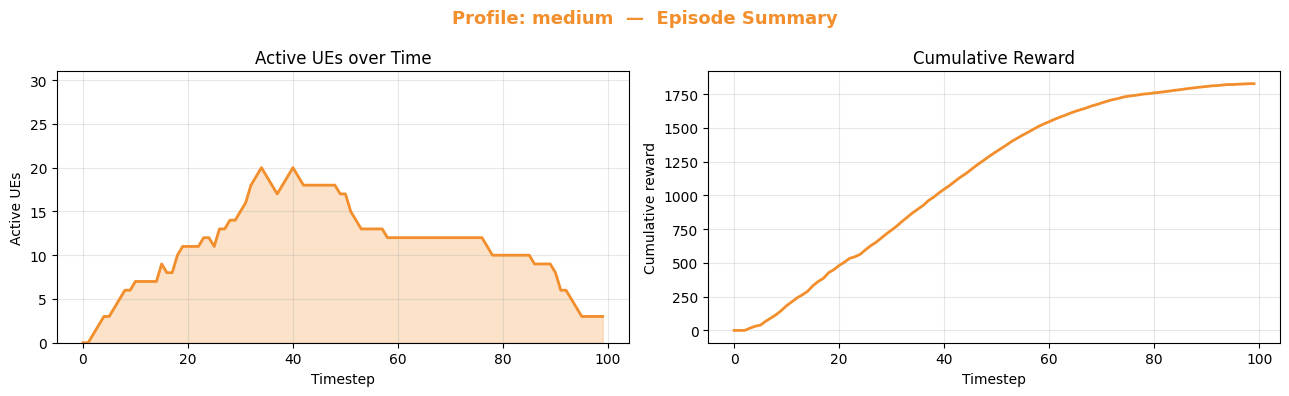

Pool            : 30 UEs
Total reward    : 1828.15
UE jobs done    : 743
UE throughput   : 46.439 MB
Mean AoRI       : 2.300 steps
Mean AoSI       : 15.400 steps
Completion rate : 0.724
Timely rate     : 0.989
Residual jobs   : 0.296


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Profile: {profile}  —  Episode Summary',
             fontsize=13, fontweight='bold', color=color)

ax1.fill_between(range(len(active_ues)), active_ues, alpha=0.25, color=color)
ax1.plot(active_ues, color=color, lw=2)
ax1.set_title('Active UEs over Time')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Active UEs')
ax1.set_ylim(0, n_ues + 1)
ax1.grid(True, alpha=0.3)

ax2.plot(np.cumsum(rewards), color=color, lw=2)
ax2.set_title('Cumulative Reward')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cumulative reward')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

throughput_mb = ue_df['data_size'].sum() / 8e6
print(f'Pool            : {n_ues} UEs')
print(f'Total reward    : {sum(rewards):.2f}')
print(f'UE jobs done    : {len(ue_df)}')
print(f'UE throughput   : {throughput_mb:.3f} MB')
print(f'Mean AoRI       : {ep.get("mean_aori", float("nan")):.3f} steps')
print(f'Mean AoSI       : {ep.get("mean_aosi", float("nan")):.3f} steps')
print(f'Completion rate : {ep.get("job_completion_rate", float("nan")):.3f}')
print(f'Timely rate     : {ep.get("timely_completion_rate", float("nan")):.3f}')
print(f'Residual jobs   : {ep.get("mean_residual_jobs_at_departure", float("nan")):.3f}')

In [8]:
# ── Exhaustive grid search: 81 combinations x N_GRID_RUNS seeds ───────────
records = []
total   = len(GRID_SPLITS) ** 2

env = make_env(profile)   # single env, reset per run

for idx, (bw_val, comp_val) in enumerate(itertools.product(GRID_SPLITS, GRID_SPLITS), start=1):
    run_aori, run_aosi, run_jobs, run_tput = [], [], [], []

    for run in range(N_GRID_RUNS):
        obs, _ = env.reset(seed=run)
        done = False

        while not done:
            obs, r, terminated, truncated, info = env.step([bw_val, comp_val])
            done = terminated or truncated

        ep  = env.metrics.finalize(env.job_tracker)
        jdf = env.job_tracker.to_dataframe()
        udf = jdf[jdf['entity_type'] == 'UE']

        if len(udf) > 0:
            mean_aori        = udf['aori'].mean()
            mean_aosi        = udf['aosi'].mean()
            jobs_done        = len(udf)
            ue_throughput_kb = udf['data_size'].sum() / 8000
        else:
            mean_aori = mean_aosi = np.nan
            jobs_done = 0
            ue_throughput_kb = 0.0

        records.append({
            'bw_split':                bw_val,
            'comp_split':              comp_val,
            'run':                     run,
            'mean_aori':               mean_aori,
            'mean_aosi':               mean_aosi,
            'jobs_done':               jobs_done,
            'ue_throughput_kb':        ue_throughput_kb,
            'completion_rate':         ep.get('job_completion_rate', 0),
            'timely_rate':             ep.get('timely_completion_rate'),
            'residual_jobs':           ep.get('mean_residual_jobs_at_departure'),
            'mean_ue_proc_queue':      ep.get('mean_ue_proc_queue'),
            'peak_ue_proc_queue':      ep.get('peak_ue_proc_queue'),
            'final_ue_proc_queue':     ep.get('final_ue_proc_queue'),
            'mean_sensor_proc_queue':  ep.get('mean_sensor_proc_queue'),
            'peak_sensor_proc_queue':  ep.get('peak_sensor_proc_queue'),
            'final_sensor_proc_queue': ep.get('final_sensor_proc_queue'),
        })
        run_aori.append(mean_aori)
        run_aosi.append(mean_aosi)
        run_jobs.append(jobs_done)
        run_tput.append(ue_throughput_kb)

    print(
        f'  [{idx:>2}/{total}]  bw={bw_val:.1f}  comp={comp_val:.1f}'
        f'  |  AoRI={np.nanmean(run_aori):6.2f}'
        f'  AoSI={np.nanmean(run_aosi):6.2f}'
        f'  jobs={int(np.nanmean(run_jobs))}'
        f'  tput={np.nanmean(run_tput):.0f} KB'
    )

env.close()

  [ 1/81]  bw=0.1  comp=0.1  |  AoRI= 25.35  AoSI= 24.37  jobs=187  tput=11689 KB
  [ 2/81]  bw=0.1  comp=0.2  |  AoRI= 24.32  AoSI= 23.34  jobs=220  tput=13752 KB
  [ 3/81]  bw=0.1  comp=0.3  |  AoRI= 24.25  AoSI= 19.50  jobs=220  tput=13752 KB
  [ 4/81]  bw=0.1  comp=0.4  |  AoRI= 24.24  AoSI= 12.65  jobs=220  tput=13752 KB
  [ 5/81]  bw=0.1  comp=0.5  |  AoRI= 24.24  AoSI=  7.17  jobs=220  tput=13752 KB
  [ 6/81]  bw=0.1  comp=0.6  |  AoRI= 24.24  AoSI=  6.35  jobs=220  tput=13752 KB
  [ 7/81]  bw=0.1  comp=0.7  |  AoRI= 24.24  AoSI=  9.88  jobs=220  tput=13752 KB
  [ 8/81]  bw=0.1  comp=0.8  |  AoRI= 24.25  AoSI= 17.06  jobs=220  tput=13752 KB
  [ 9/81]  bw=0.1  comp=0.9  |  AoRI= 24.33  AoSI= 24.38  jobs=220  tput=13752 KB
  [10/81]  bw=0.2  comp=0.1  |  AoRI= 28.79  AoSI= 27.65  jobs=192  tput=12001 KB
  [11/81]  bw=0.2  comp=0.2  |  AoRI= 17.89  AoSI= 16.68  jobs=376  tput=23501 KB
  [12/81]  bw=0.2  comp=0.3  |  AoRI= 14.97  AoSI= 10.58  jobs=437  tput=27313 KB
  [13/81]  bw=0.

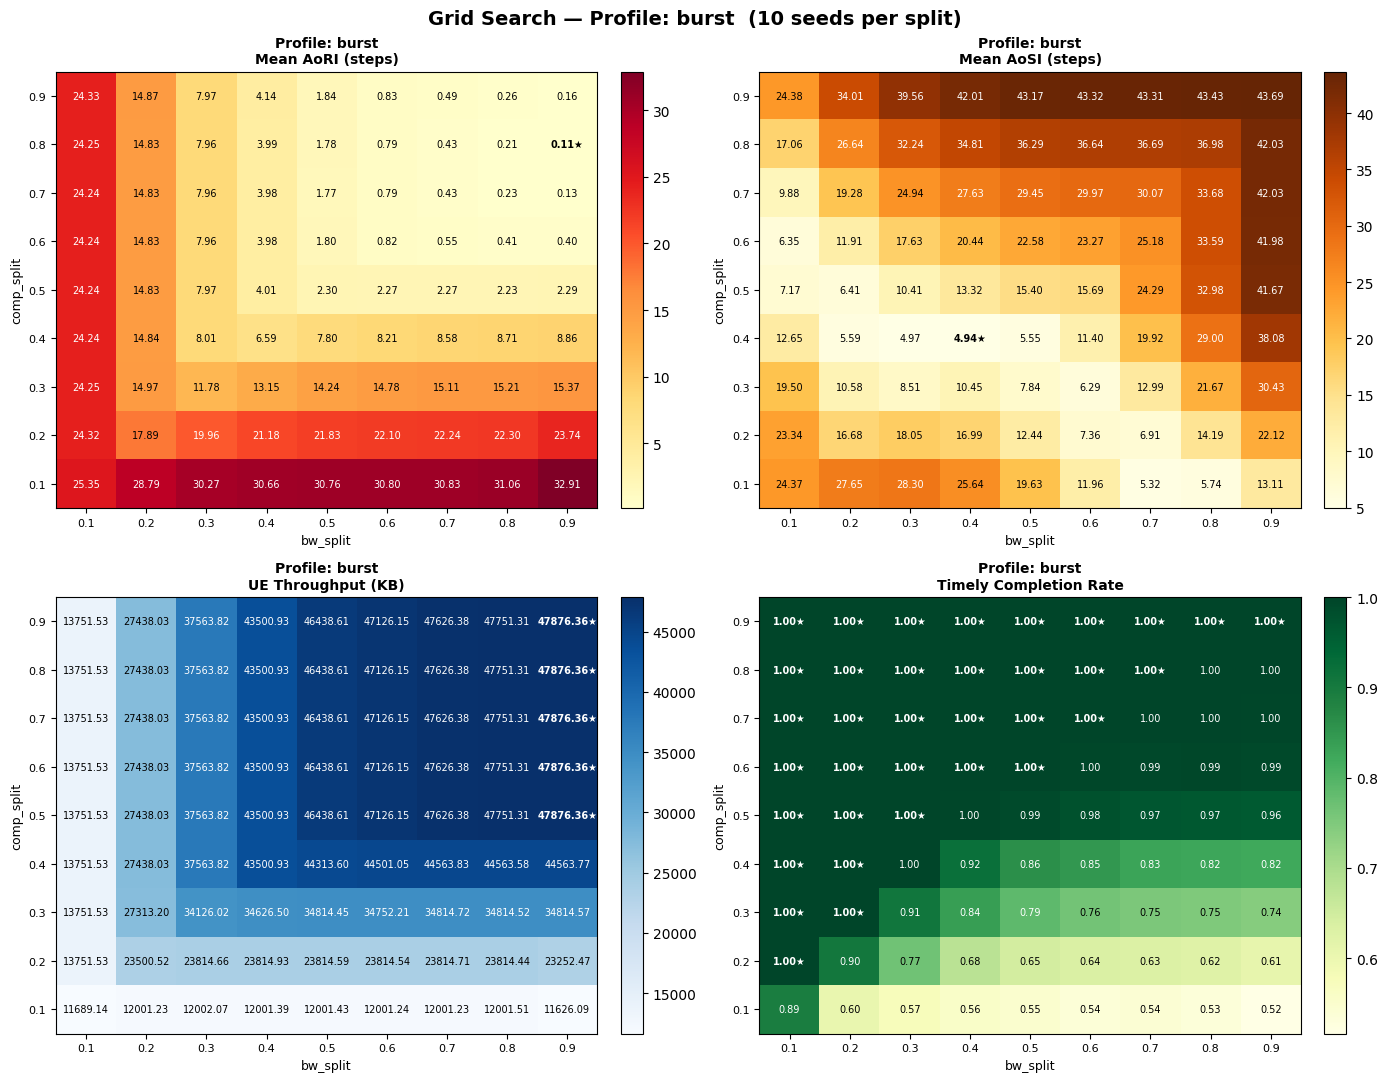

Best splits per metric:
Metric                          bw_split  comp_split       value
-----------------------------------------------------------------
Mean AoRI (steps)                    0.9         0.8       0.110
Mean AoSI (steps)                    0.4         0.4       4.937
UE Throughput (KB)                   0.9         0.5   47876.356
Completion Rate                      0.2         0.2       0.891
Timely Completion Rate               0.1         0.2       1.000
Residual Jobs at Departure           0.1         0.2       0.000


In [9]:
# ── Aggregate ─────────────────────────────────────────────────────────────
raw_df = pd.DataFrame(records)
summ = (
    raw_df.groupby(['bw_split', 'comp_split'])
    .agg(
        mean_aosi          =('mean_aosi',        'mean'),
        mean_aori          =('mean_aori',        'mean'),
        mean_throughput_kb =('ue_throughput_kb', 'mean'),
        mean_completion    =('completion_rate',  'mean'),
        mean_timely        =('timely_rate',      'mean'),
        mean_residual      =('residual_jobs',    'mean'),
    )
    .reset_index()
)

# ── Heatmaps (2x2): AoRI · AoSI · Throughput · Timely Completion Rate ───
HEATMAP_METRICS = [
    ('mean_aori',          'Mean AoRI (steps)',       'YlOrRd', np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',       'YlOrBr', np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',      'Blues',  np.nanmax),
    ('mean_timely',        'Timely Completion Rate',  'YlGn',   np.nanmax),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Grid Search — Profile: burst  (10 seeds per split)',
             fontsize=14, fontweight='bold')

for ax, (col, title, cmap, best_fn) in zip(axes.flat, HEATMAP_METRICS):
    draw_heatmap(ax, summ, col, title, cmap, best_fn, 'Profile: burst')

plt.tight_layout()
plt.show()

# ── All 6 metrics — best splits summary ──────────────────────────────────
print('Best splits per metric:')
print(f'{"Metric":<30s}  {"bw_split":>8s}  {"comp_split":>10s}  {"value":>10s}')
print('-' * 65)
for col, label, best_fn in [
    ('mean_aori',          'Mean AoRI (steps)',          np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',          np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',         np.nanmax),
    ('mean_completion',    'Completion Rate',            np.nanmax),
    ('mean_timely',        'Timely Completion Rate',     np.nanmax),
    ('mean_residual',      'Residual Jobs at Departure', np.nanmin),
]:
    valid = summ[col].dropna()
    if valid.empty:
        print(label.ljust(30) + '  ' + 'N/A')
        continue
    best_val = best_fn(valid)
    row = summ[np.isclose(summ[col], best_val)].iloc[0]
    print(f'{label:<30s}  {row.bw_split:>8.1f}  {row.comp_split:>10.1f}  {best_val:>10.3f}')

---
## Profile: `high`

Heavy cell — all UEs arrive in first 15 steps, long sojourn.

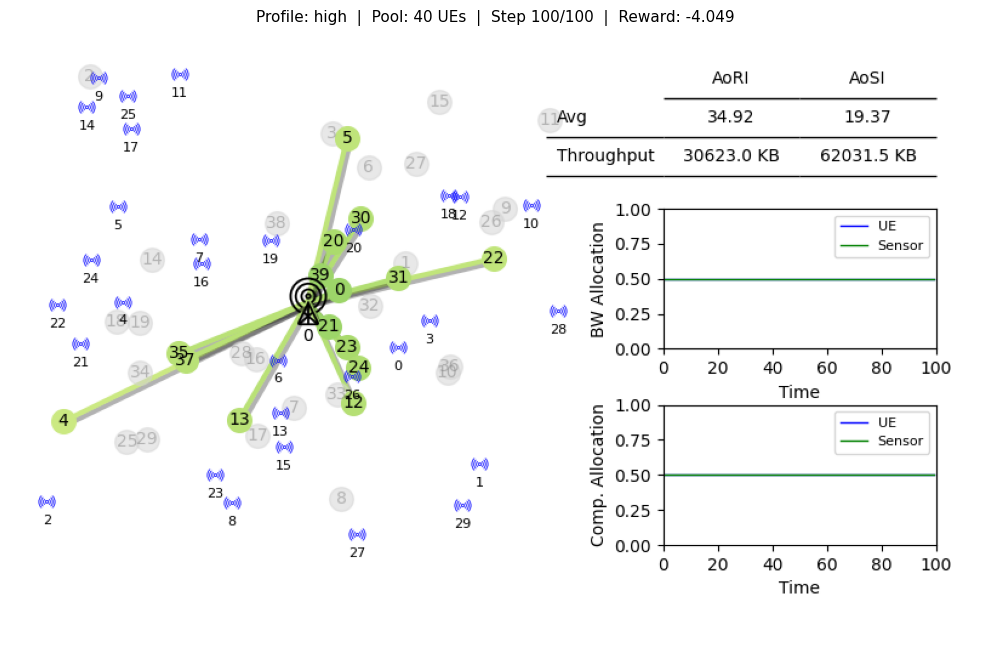

Episode complete — 100 steps  |   Total reward: 1095.70


In [10]:
profile = 'high'
n_ues  = DynamicArrival.POOL_SIZE[profile]
color  = COLORS[profile]
env    = make_env(profile)
obs, _ = env.reset()

rewards, active_ues = [], []
done = False

while not done:
    obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
    rewards.append(reward)
    active_ues.append(env.metrics.latest('num_active_ues'))
    done = terminated or truncated

    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Profile: {profile}  |  Pool: {n_ues} UEs  |  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
        fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

job_df = env.job_tracker.to_dataframe()
ue_df  = job_df[job_df['entity_type'] == 'UE']
ep     = env.metrics.finalize(env.job_tracker)
env.close()
print(f'Episode complete — {len(rewards)} steps  |   Total reward: {sum(rewards):.2f}')

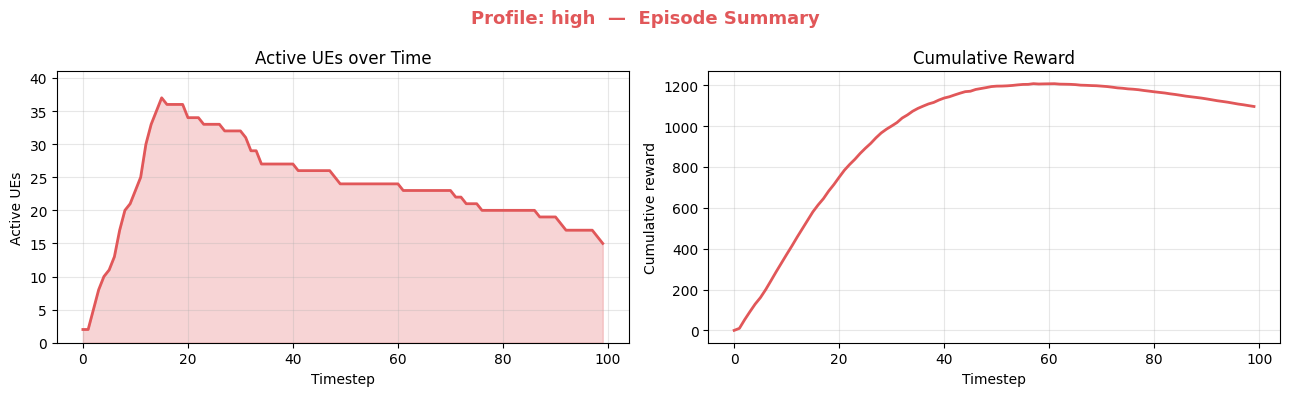

Pool            : 40 UEs
Total reward    : 1095.70
UE jobs done    : 490
UE throughput   : 30.623 MB
Mean AoRI       : 34.922 steps
Mean AoSI       : 19.371 steps
Completion rate : 0.484
Timely rate     : 0.806
Residual jobs   : 11.920


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Profile: {profile}  —  Episode Summary',
             fontsize=13, fontweight='bold', color=color)

ax1.fill_between(range(len(active_ues)), active_ues, alpha=0.25, color=color)
ax1.plot(active_ues, color=color, lw=2)
ax1.set_title('Active UEs over Time')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Active UEs')
ax1.set_ylim(0, n_ues + 1)
ax1.grid(True, alpha=0.3)

ax2.plot(np.cumsum(rewards), color=color, lw=2)
ax2.set_title('Cumulative Reward')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cumulative reward')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

throughput_mb = ue_df['data_size'].sum() / 8e6
print(f'Pool            : {n_ues} UEs')
print(f'Total reward    : {sum(rewards):.2f}')
print(f'UE jobs done    : {len(ue_df)}')
print(f'UE throughput   : {throughput_mb:.3f} MB')
print(f'Mean AoRI       : {ep.get("mean_aori", float("nan")):.3f} steps')
print(f'Mean AoSI       : {ep.get("mean_aosi", float("nan")):.3f} steps')
print(f'Completion rate : {ep.get("job_completion_rate", float("nan")):.3f}')
print(f'Timely rate     : {ep.get("timely_completion_rate", float("nan")):.3f}')
print(f'Residual jobs   : {ep.get("mean_residual_jobs_at_departure", float("nan")):.3f}')

In [12]:
# ── Exhaustive grid search: 81 combinations x N_GRID_RUNS seeds ───────────
records = []
total   = len(GRID_SPLITS) ** 2

env = make_env(profile)   # single env, reset per run

for idx, (bw_val, comp_val) in enumerate(itertools.product(GRID_SPLITS, GRID_SPLITS), start=1):
    run_aori, run_aosi, run_jobs, run_tput = [], [], [], []

    for run in range(N_GRID_RUNS):
        obs, _ = env.reset(seed=run)
        done = False

        while not done:
            obs, r, terminated, truncated, info = env.step([bw_val, comp_val])
            done = terminated or truncated

        ep  = env.metrics.finalize(env.job_tracker)
        jdf = env.job_tracker.to_dataframe()
        udf = jdf[jdf['entity_type'] == 'UE']

        if len(udf) > 0:
            mean_aori        = udf['aori'].mean()
            mean_aosi        = udf['aosi'].mean()
            jobs_done        = len(udf)
            ue_throughput_kb = udf['data_size'].sum() / 8000
        else:
            mean_aori = mean_aosi = np.nan
            jobs_done = 0
            ue_throughput_kb = 0.0

        records.append({
            'bw_split':                bw_val,
            'comp_split':              comp_val,
            'run':                     run,
            'mean_aori':               mean_aori,
            'mean_aosi':               mean_aosi,
            'jobs_done':               jobs_done,
            'ue_throughput_kb':        ue_throughput_kb,
            'completion_rate':         ep.get('job_completion_rate', 0),
            'timely_rate':             ep.get('timely_completion_rate'),
            'residual_jobs':           ep.get('mean_residual_jobs_at_departure'),
            'mean_ue_proc_queue':      ep.get('mean_ue_proc_queue'),
            'peak_ue_proc_queue':      ep.get('peak_ue_proc_queue'),
            'final_ue_proc_queue':     ep.get('final_ue_proc_queue'),
            'mean_sensor_proc_queue':  ep.get('mean_sensor_proc_queue'),
            'peak_sensor_proc_queue':  ep.get('peak_sensor_proc_queue'),
            'final_sensor_proc_queue': ep.get('final_sensor_proc_queue'),
        })
        run_aori.append(mean_aori)
        run_aosi.append(mean_aosi)
        run_jobs.append(jobs_done)
        run_tput.append(ue_throughput_kb)

    print(
        f'  [{idx:>2}/{total}]  bw={bw_val:.1f}  comp={comp_val:.1f}'
        f'  |  AoRI={np.nanmean(run_aori):6.2f}'
        f'  AoSI={np.nanmean(run_aosi):6.2f}'
        f'  jobs={int(np.nanmean(run_jobs))}'
        f'  tput={np.nanmean(run_tput):.0f} KB'
    )

env.close()

  [ 1/81]  bw=0.1  comp=0.1  |  AoRI= 41.94  AoSI= 40.94  jobs=97  tput=6061 KB
  [ 2/81]  bw=0.1  comp=0.2  |  AoRI= 42.16  AoSI= 41.16  jobs=184  tput=11500 KB
  [ 3/81]  bw=0.1  comp=0.3  |  AoRI= 42.51  AoSI= 37.90  jobs=239  tput=14937 KB
  [ 4/81]  bw=0.1  comp=0.4  |  AoRI= 42.84  AoSI= 30.74  jobs=244  tput=15249 KB
  [ 5/81]  bw=0.1  comp=0.5  |  AoRI= 42.87  AoSI= 23.29  jobs=245  tput=15312 KB
  [ 6/81]  bw=0.1  comp=0.6  |  AoRI= 42.83  AoSI= 15.89  jobs=245  tput=15312 KB
  [ 7/81]  bw=0.1  comp=0.7  |  AoRI= 42.81  AoSI=  8.96  jobs=245  tput=15312 KB
  [ 8/81]  bw=0.1  comp=0.8  |  AoRI= 42.80  AoSI=  3.70  jobs=245  tput=15312 KB
  [ 9/81]  bw=0.1  comp=0.9  |  AoRI= 42.81  AoSI=  6.53  jobs=245  tput=15312 KB
  [10/81]  bw=0.2  comp=0.1  |  AoRI= 42.49  AoSI= 41.42  jobs=98  tput=6123 KB
  [11/81]  bw=0.2  comp=0.2  |  AoRI= 39.74  AoSI= 38.63  jobs=197  tput=12312 KB
  [12/81]  bw=0.2  comp=0.3  |  AoRI= 37.94  AoSI= 33.83  jobs=292  tput=18248 KB
  [13/81]  bw=0.2  c

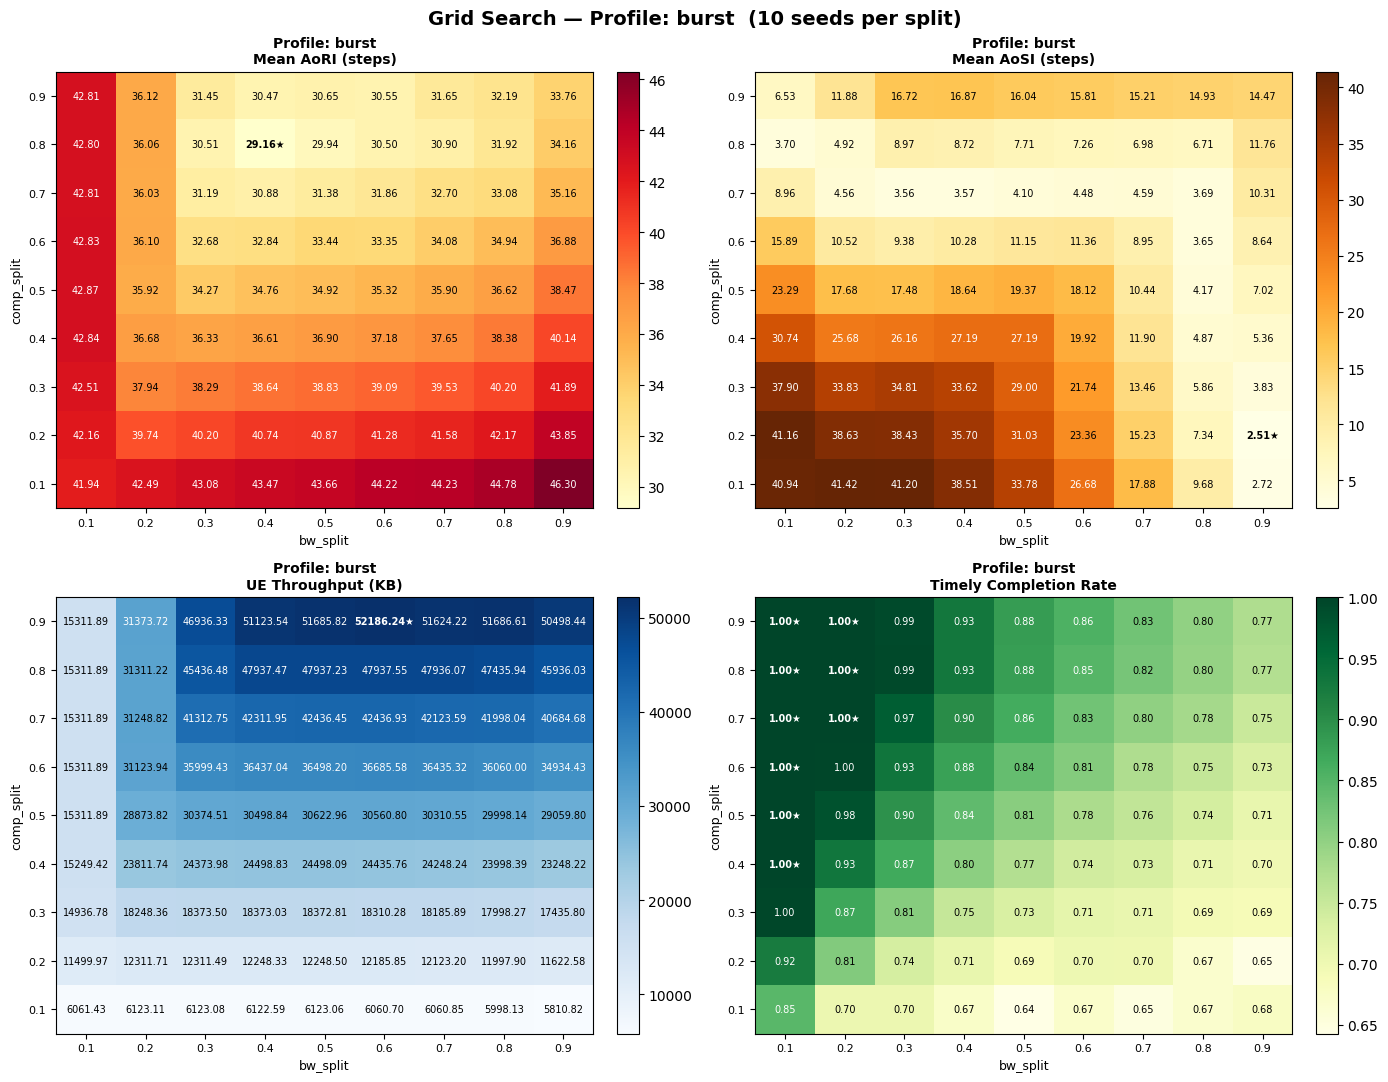

Best splits per metric:
Metric                          bw_split  comp_split       value
-----------------------------------------------------------------
Mean AoRI (steps)                    0.4         0.8      29.159
Mean AoSI (steps)                    0.9         0.2       2.511
UE Throughput (KB)                   0.6         0.9   52186.242
Completion Rate                      0.1         0.2       0.623
Timely Completion Rate               0.1         0.4       1.000
Residual Jobs at Departure           0.1         0.4       0.000


In [13]:
# ── Aggregate ─────────────────────────────────────────────────────────────
raw_df = pd.DataFrame(records)
summ = (
    raw_df.groupby(['bw_split', 'comp_split'])
    .agg(
        mean_aosi          =('mean_aosi',        'mean'),
        mean_aori          =('mean_aori',        'mean'),
        mean_throughput_kb =('ue_throughput_kb', 'mean'),
        mean_completion    =('completion_rate',  'mean'),
        mean_timely        =('timely_rate',      'mean'),
        mean_residual      =('residual_jobs',    'mean'),
    )
    .reset_index()
)

# ── Heatmaps (2x2): AoRI · AoSI · Throughput · Timely Completion Rate ───
HEATMAP_METRICS = [
    ('mean_aori',          'Mean AoRI (steps)',       'YlOrRd', np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',       'YlOrBr', np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',      'Blues',  np.nanmax),
    ('mean_timely',        'Timely Completion Rate',  'YlGn',   np.nanmax),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Grid Search — Profile: burst  (10 seeds per split)',
             fontsize=14, fontweight='bold')

for ax, (col, title, cmap, best_fn) in zip(axes.flat, HEATMAP_METRICS):
    draw_heatmap(ax, summ, col, title, cmap, best_fn, 'Profile: burst')

plt.tight_layout()
plt.show()

# ── All 6 metrics — best splits summary ──────────────────────────────────
print('Best splits per metric:')
print(f'{"Metric":<30s}  {"bw_split":>8s}  {"comp_split":>10s}  {"value":>10s}')
print('-' * 65)
for col, label, best_fn in [
    ('mean_aori',          'Mean AoRI (steps)',          np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',          np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',         np.nanmax),
    ('mean_completion',    'Completion Rate',            np.nanmax),
    ('mean_timely',        'Timely Completion Rate',     np.nanmax),
    ('mean_residual',      'Residual Jobs at Departure', np.nanmin),
]:
    valid = summ[col].dropna()
    if valid.empty:
        print(label.ljust(30) + '  ' + 'N/A')
        continue
    best_val = best_fn(valid)
    row = summ[np.isclose(summ[col], best_val)].iloc[0]
    print(f'{label:<30s}  {row.bw_split:>8.1f}  {row.comp_split:>10.1f}  {best_val:>10.3f}')

---
## Profile: `ramp_up`

No arrivals before step 30 — load builds gradually to a peak.

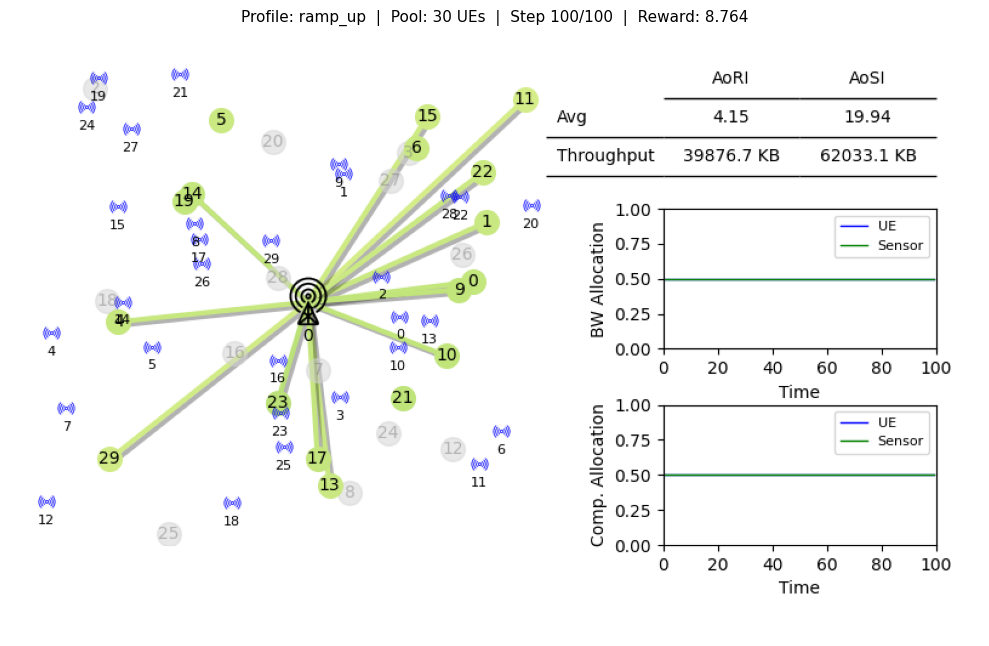

Episode complete — 100 steps  |   Total reward: 408.25


In [14]:
profile = 'ramp_up'
n_ues  = DynamicArrival.POOL_SIZE[profile]
color  = COLORS[profile]
env    = make_env(profile)
obs, _ = env.reset()

rewards, active_ues = [], []
done = False

while not done:
    obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
    rewards.append(reward)
    active_ues.append(env.metrics.latest('num_active_ues'))
    done = terminated or truncated

    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Profile: {profile}  |  Pool: {n_ues} UEs  |  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
        fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

job_df = env.job_tracker.to_dataframe()
ue_df  = job_df[job_df['entity_type'] == 'UE']
ep     = env.metrics.finalize(env.job_tracker)
env.close()
print(f'Episode complete — {len(rewards)} steps  |   Total reward: {sum(rewards):.2f}')

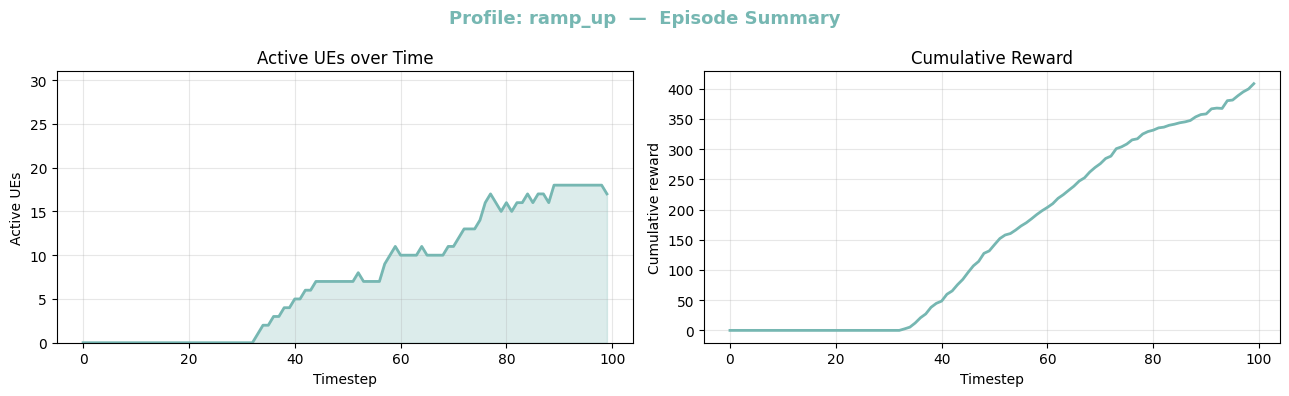

Pool            : 30 UEs
Total reward    : 408.25
UE jobs done    : 319
UE throughput   : 39.877 MB
Mean AoRI       : 4.150 steps
Mean AoSI       : 19.940 steps
Completion rate : 0.653
Timely rate     : 1.000
Residual jobs   : 0.000


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Profile: {profile}  —  Episode Summary',
             fontsize=13, fontweight='bold', color=color)

ax1.fill_between(range(len(active_ues)), active_ues, alpha=0.25, color=color)
ax1.plot(active_ues, color=color, lw=2)
ax1.set_title('Active UEs over Time')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Active UEs')
ax1.set_ylim(0, n_ues + 1)
ax1.grid(True, alpha=0.3)

ax2.plot(np.cumsum(rewards), color=color, lw=2)
ax2.set_title('Cumulative Reward')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cumulative reward')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

throughput_mb = ue_df['data_size'].sum() / 8e6
print(f'Pool            : {n_ues} UEs')
print(f'Total reward    : {sum(rewards):.2f}')
print(f'UE jobs done    : {len(ue_df)}')
print(f'UE throughput   : {throughput_mb:.3f} MB')
print(f'Mean AoRI       : {ep.get("mean_aori", float("nan")):.3f} steps')
print(f'Mean AoSI       : {ep.get("mean_aosi", float("nan")):.3f} steps')
print(f'Completion rate : {ep.get("job_completion_rate", float("nan")):.3f}')
print(f'Timely rate     : {ep.get("timely_completion_rate", float("nan")):.3f}')
print(f'Residual jobs   : {ep.get("mean_residual_jobs_at_departure", float("nan")):.3f}')

In [16]:
# ── Exhaustive grid search: 81 combinations x N_GRID_RUNS seeds ───────────
records = []
total   = len(GRID_SPLITS) ** 2

env = make_env(profile)   # single env, reset per run

for idx, (bw_val, comp_val) in enumerate(itertools.product(GRID_SPLITS, GRID_SPLITS), start=1):
    run_aori, run_aosi, run_jobs, run_tput = [], [], [], []

    for run in range(N_GRID_RUNS):
        obs, _ = env.reset(seed=run)
        done = False

        while not done:
            obs, r, terminated, truncated, info = env.step([bw_val, comp_val])
            done = terminated or truncated

        ep  = env.metrics.finalize(env.job_tracker)
        jdf = env.job_tracker.to_dataframe()
        udf = jdf[jdf['entity_type'] == 'UE']

        if len(udf) > 0:
            mean_aori        = udf['aori'].mean()
            mean_aosi        = udf['aosi'].mean()
            jobs_done        = len(udf)
            ue_throughput_kb = udf['data_size'].sum() / 8000
        else:
            mean_aori = mean_aosi = np.nan
            jobs_done = 0
            ue_throughput_kb = 0.0

        records.append({
            'bw_split':                bw_val,
            'comp_split':              comp_val,
            'run':                     run,
            'mean_aori':               mean_aori,
            'mean_aosi':               mean_aosi,
            'jobs_done':               jobs_done,
            'ue_throughput_kb':        ue_throughput_kb,
            'completion_rate':         ep.get('job_completion_rate', 0),
            'timely_rate':             ep.get('timely_completion_rate'),
            'residual_jobs':           ep.get('mean_residual_jobs_at_departure'),
            'mean_ue_proc_queue':      ep.get('mean_ue_proc_queue'),
            'peak_ue_proc_queue':      ep.get('peak_ue_proc_queue'),
            'final_ue_proc_queue':     ep.get('final_ue_proc_queue'),
            'mean_sensor_proc_queue':  ep.get('mean_sensor_proc_queue'),
            'peak_sensor_proc_queue':  ep.get('peak_sensor_proc_queue'),
            'final_sensor_proc_queue': ep.get('final_sensor_proc_queue'),
        })
        run_aori.append(mean_aori)
        run_aosi.append(mean_aosi)
        run_jobs.append(jobs_done)
        run_tput.append(ue_throughput_kb)

    print(
        f'  [{idx:>2}/{total}]  bw={bw_val:.1f}  comp={comp_val:.1f}'
        f'  |  AoRI={np.nanmean(run_aori):6.2f}'
        f'  AoSI={np.nanmean(run_aosi):6.2f}'
        f'  jobs={int(np.nanmean(run_jobs))}'
        f'  tput={np.nanmean(run_tput):.0f} KB'
    )

env.close()

  [ 1/81]  bw=0.1  comp=0.1  |  AoRI= 14.22  AoSI= 13.25  jobs=63  tput=7875 KB
  [ 2/81]  bw=0.1  comp=0.2  |  AoRI= 14.10  AoSI= 13.13  jobs=63  tput=7875 KB
  [ 3/81]  bw=0.1  comp=0.3  |  AoRI= 14.10  AoSI=  9.03  jobs=63  tput=7875 KB
  [ 4/81]  bw=0.1  comp=0.4  |  AoRI= 14.10  AoSI=  6.08  jobs=63  tput=7875 KB
  [ 5/81]  bw=0.1  comp=0.5  |  AoRI= 14.10  AoSI=  9.76  jobs=63  tput=7875 KB
  [ 6/81]  bw=0.1  comp=0.6  |  AoRI= 14.10  AoSI= 17.57  jobs=63  tput=7875 KB
  [ 7/81]  bw=0.1  comp=0.7  |  AoRI= 14.10  AoSI= 26.22  jobs=63  tput=7875 KB
  [ 8/81]  bw=0.1  comp=0.8  |  AoRI= 14.10  AoSI= 34.98  jobs=63  tput=7875 KB
  [ 9/81]  bw=0.1  comp=0.9  |  AoRI= 14.10  AoSI= 43.63  jobs=63  tput=7875 KB
  [10/81]  bw=0.2  comp=0.1  |  AoRI= 10.50  AoSI=  9.41  jobs=136  tput=17001 KB
  [11/81]  bw=0.2  comp=0.2  |  AoRI= 10.21  AoSI=  9.13  jobs=137  tput=17126 KB
  [12/81]  bw=0.2  comp=0.3  |  AoRI= 10.21  AoSI=  6.06  jobs=137  tput=17126 KB
  [13/81]  bw=0.2  comp=0.4  |  Ao

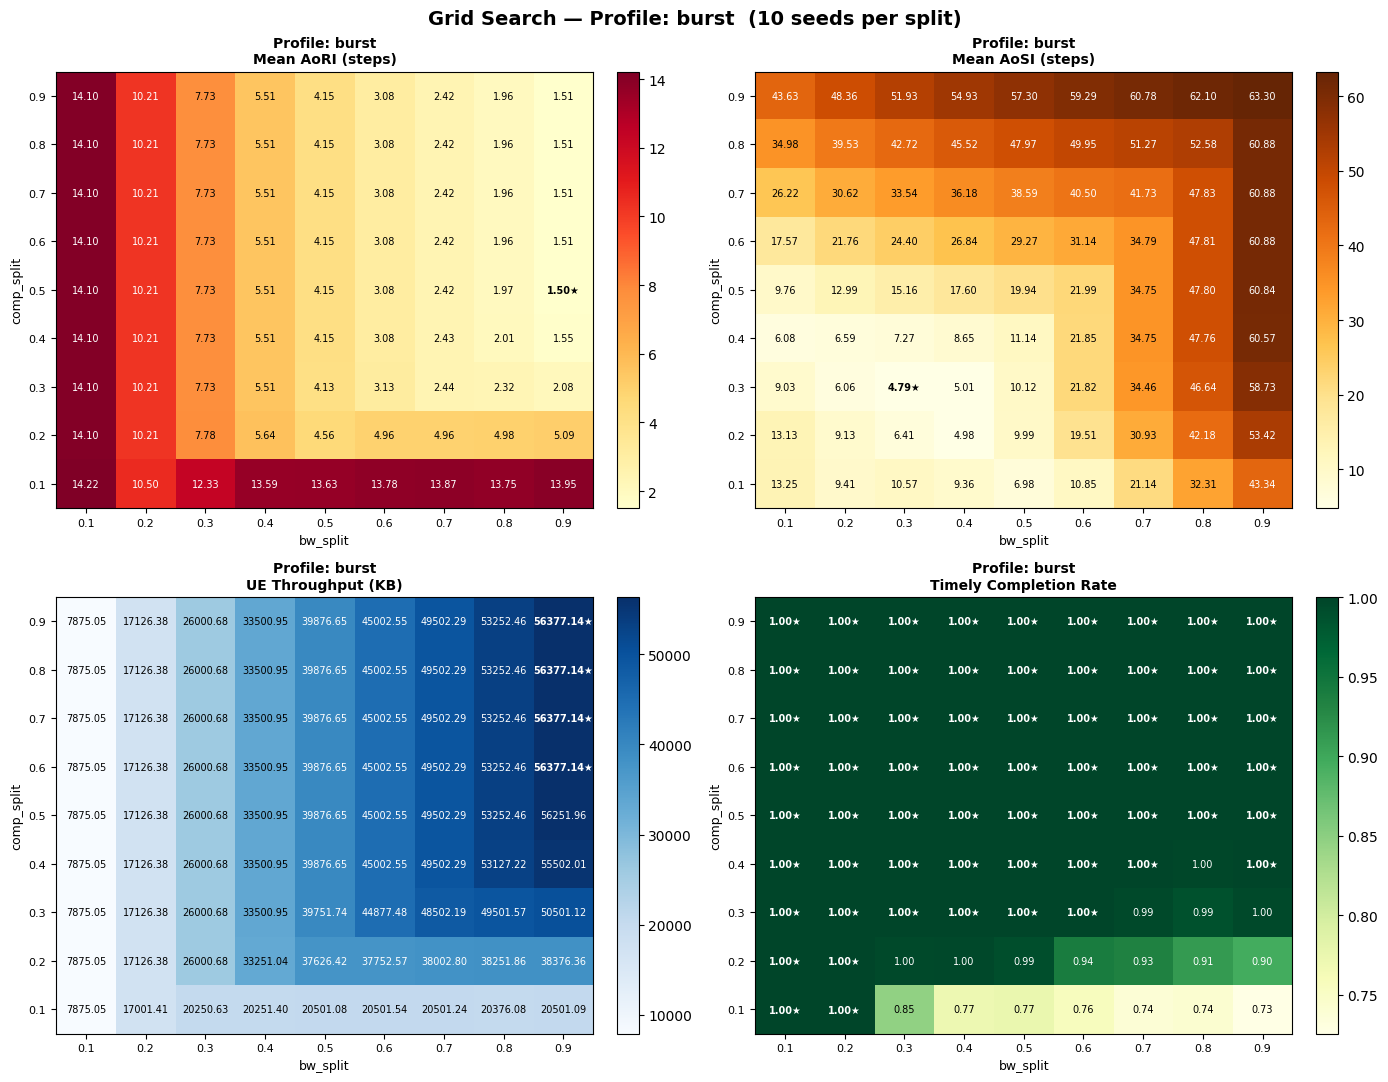

Best splits per metric:
Metric                          bw_split  comp_split       value
-----------------------------------------------------------------
Mean AoRI (steps)                    0.9         0.5       1.500
Mean AoSI (steps)                    0.3         0.3       4.793
UE Throughput (KB)                   0.9         0.6   56377.140
Completion Rate                      0.2         0.2       0.883
Timely Completion Rate               0.1         0.1       1.000
Residual Jobs at Departure           0.1         0.1       0.000


In [17]:
# ── Aggregate ─────────────────────────────────────────────────────────────
raw_df = pd.DataFrame(records)
summ = (
    raw_df.groupby(['bw_split', 'comp_split'])
    .agg(
        mean_aosi          =('mean_aosi',        'mean'),
        mean_aori          =('mean_aori',        'mean'),
        mean_throughput_kb =('ue_throughput_kb', 'mean'),
        mean_completion    =('completion_rate',  'mean'),
        mean_timely        =('timely_rate',      'mean'),
        mean_residual      =('residual_jobs',    'mean'),
    )
    .reset_index()
)

# ── Heatmaps (2x2): AoRI · AoSI · Throughput · Timely Completion Rate ───
HEATMAP_METRICS = [
    ('mean_aori',          'Mean AoRI (steps)',       'YlOrRd', np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',       'YlOrBr', np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',      'Blues',  np.nanmax),
    ('mean_timely',        'Timely Completion Rate',  'YlGn',   np.nanmax),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Grid Search — Profile: burst  (10 seeds per split)',
             fontsize=14, fontweight='bold')

for ax, (col, title, cmap, best_fn) in zip(axes.flat, HEATMAP_METRICS):
    draw_heatmap(ax, summ, col, title, cmap, best_fn, 'Profile: burst')

plt.tight_layout()
plt.show()

# ── All 6 metrics — best splits summary ──────────────────────────────────
print('Best splits per metric:')
print(f'{"Metric":<30s}  {"bw_split":>8s}  {"comp_split":>10s}  {"value":>10s}')
print('-' * 65)
for col, label, best_fn in [
    ('mean_aori',          'Mean AoRI (steps)',          np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',          np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',         np.nanmax),
    ('mean_completion',    'Completion Rate',            np.nanmax),
    ('mean_timely',        'Timely Completion Rate',     np.nanmax),
    ('mean_residual',      'Residual Jobs at Departure', np.nanmin),
]:
    valid = summ[col].dropna()
    if valid.empty:
        print(label.ljust(30) + '  ' + 'N/A')
        continue
    best_val = best_fn(valid)
    row = summ[np.isclose(summ[col], best_val)].iloc[0]
    print(f'{label:<30s}  {row.bw_split:>8.1f}  {row.comp_split:>10.1f}  {best_val:>10.3f}')

---
## Profile: `ramp_down`

Arrivals in first 15 steps, short sojourn — network drains quickly.

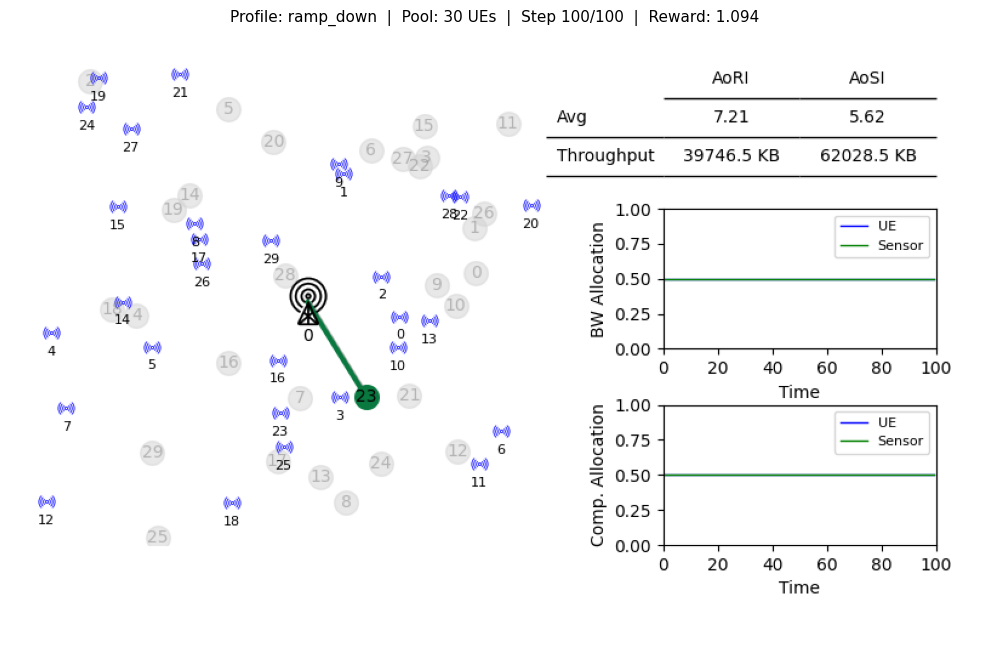

Episode complete — 100 steps  |   Total reward: 2909.34


In [18]:
profile = 'ramp_down'
n_ues  = DynamicArrival.POOL_SIZE[profile]
color  = COLORS[profile]
env    = make_env(profile)
obs, _ = env.reset()

rewards, active_ues = [], []
done = False

while not done:
    obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
    rewards.append(reward)
    active_ues.append(env.metrics.latest('num_active_ues'))
    done = terminated or truncated

    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Profile: {profile}  |  Pool: {n_ues} UEs  |  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
        fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

job_df = env.job_tracker.to_dataframe()
ue_df  = job_df[job_df['entity_type'] == 'UE']
ep     = env.metrics.finalize(env.job_tracker)
env.close()
print(f'Episode complete — {len(rewards)} steps  |   Total reward: {sum(rewards):.2f}')

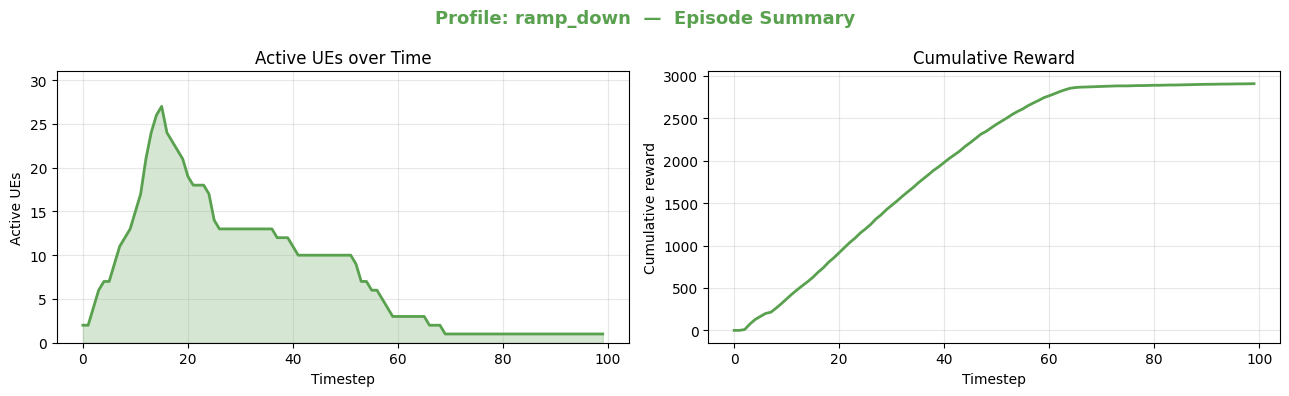

Pool            : 30 UEs
Total reward    : 2909.34
UE jobs done    : 530
UE throughput   : 39.747 MB
Mean AoRI       : 7.206 steps
Mean AoSI       : 5.623 steps
Completion rate : 0.690
Timely rate     : 0.896
Residual jobs   : 1.897


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Profile: {profile}  —  Episode Summary',
             fontsize=13, fontweight='bold', color=color)

ax1.fill_between(range(len(active_ues)), active_ues, alpha=0.25, color=color)
ax1.plot(active_ues, color=color, lw=2)
ax1.set_title('Active UEs over Time')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Active UEs')
ax1.set_ylim(0, n_ues + 1)
ax1.grid(True, alpha=0.3)

ax2.plot(np.cumsum(rewards), color=color, lw=2)
ax2.set_title('Cumulative Reward')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cumulative reward')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

throughput_mb = ue_df['data_size'].sum() / 8e6
print(f'Pool            : {n_ues} UEs')
print(f'Total reward    : {sum(rewards):.2f}')
print(f'UE jobs done    : {len(ue_df)}')
print(f'UE throughput   : {throughput_mb:.3f} MB')
print(f'Mean AoRI       : {ep.get("mean_aori", float("nan")):.3f} steps')
print(f'Mean AoSI       : {ep.get("mean_aosi", float("nan")):.3f} steps')
print(f'Completion rate : {ep.get("job_completion_rate", float("nan")):.3f}')
print(f'Timely rate     : {ep.get("timely_completion_rate", float("nan")):.3f}')
print(f'Residual jobs   : {ep.get("mean_residual_jobs_at_departure", float("nan")):.3f}')

In [20]:
# ── Exhaustive grid search: 81 combinations x N_GRID_RUNS seeds ───────────
records = []
total   = len(GRID_SPLITS) ** 2

env = make_env(profile)   # single env, reset per run

for idx, (bw_val, comp_val) in enumerate(itertools.product(GRID_SPLITS, GRID_SPLITS), start=1):
    run_aori, run_aosi, run_jobs, run_tput = [], [], [], []

    for run in range(N_GRID_RUNS):
        obs, _ = env.reset(seed=run)
        done = False

        while not done:
            obs, r, terminated, truncated, info = env.step([bw_val, comp_val])
            done = terminated or truncated

        ep  = env.metrics.finalize(env.job_tracker)
        jdf = env.job_tracker.to_dataframe()
        udf = jdf[jdf['entity_type'] == 'UE']

        if len(udf) > 0:
            mean_aori        = udf['aori'].mean()
            mean_aosi        = udf['aosi'].mean()
            jobs_done        = len(udf)
            ue_throughput_kb = udf['data_size'].sum() / 8000
        else:
            mean_aori = mean_aosi = np.nan
            jobs_done = 0
            ue_throughput_kb = 0.0

        records.append({
            'bw_split':                bw_val,
            'comp_split':              comp_val,
            'run':                     run,
            'mean_aori':               mean_aori,
            'mean_aosi':               mean_aosi,
            'jobs_done':               jobs_done,
            'ue_throughput_kb':        ue_throughput_kb,
            'completion_rate':         ep.get('job_completion_rate', 0),
            'timely_rate':             ep.get('timely_completion_rate'),
            'residual_jobs':           ep.get('mean_residual_jobs_at_departure'),
            'mean_ue_proc_queue':      ep.get('mean_ue_proc_queue'),
            'peak_ue_proc_queue':      ep.get('peak_ue_proc_queue'),
            'final_ue_proc_queue':     ep.get('final_ue_proc_queue'),
            'mean_sensor_proc_queue':  ep.get('mean_sensor_proc_queue'),
            'peak_sensor_proc_queue':  ep.get('peak_sensor_proc_queue'),
            'final_sensor_proc_queue': ep.get('final_sensor_proc_queue'),
        })
        run_aori.append(mean_aori)
        run_aosi.append(mean_aosi)
        run_jobs.append(jobs_done)
        run_tput.append(ue_throughput_kb)

    print(
        f'  [{idx:>2}/{total}]  bw={bw_val:.1f}  comp={comp_val:.1f}'
        f'  |  AoRI={np.nanmean(run_aori):6.2f}'
        f'  AoSI={np.nanmean(run_aosi):6.2f}'
        f'  jobs={int(np.nanmean(run_jobs))}'
        f'  tput={np.nanmean(run_tput):.0f} KB'
    )

env.close()

  [ 1/81]  bw=0.1  comp=0.1  |  AoRI= 31.79  AoSI= 30.79  jobs=151  tput=11324 KB
  [ 2/81]  bw=0.1  comp=0.2  |  AoRI= 20.74  AoSI= 19.89  jobs=174  tput=13049 KB
  [ 3/81]  bw=0.1  comp=0.3  |  AoRI= 20.69  AoSI= 17.38  jobs=174  tput=13049 KB
  [ 4/81]  bw=0.1  comp=0.4  |  AoRI= 20.69  AoSI= 13.76  jobs=174  tput=13049 KB
  [ 5/81]  bw=0.1  comp=0.5  |  AoRI= 20.70  AoSI= 11.51  jobs=174  tput=13049 KB
  [ 6/81]  bw=0.1  comp=0.6  |  AoRI= 20.70  AoSI= 10.63  jobs=174  tput=13049 KB
  [ 7/81]  bw=0.1  comp=0.7  |  AoRI= 20.70  AoSI= 12.42  jobs=174  tput=13049 KB
  [ 8/81]  bw=0.1  comp=0.8  |  AoRI= 20.70  AoSI= 17.48  jobs=174  tput=13049 KB
  [ 9/81]  bw=0.1  comp=0.9  |  AoRI= 20.84  AoSI= 24.17  jobs=174  tput=13049 KB
  [10/81]  bw=0.2  comp=0.1  |  AoRI= 37.15  AoSI= 35.85  jobs=165  tput=12375 KB
  [11/81]  bw=0.2  comp=0.2  |  AoRI= 20.01  AoSI= 18.93  jobs=287  tput=21524 KB
  [12/81]  bw=0.2  comp=0.3  |  AoRI= 14.71  AoSI= 11.93  jobs=287  tput=21524 KB
  [13/81]  bw=0.

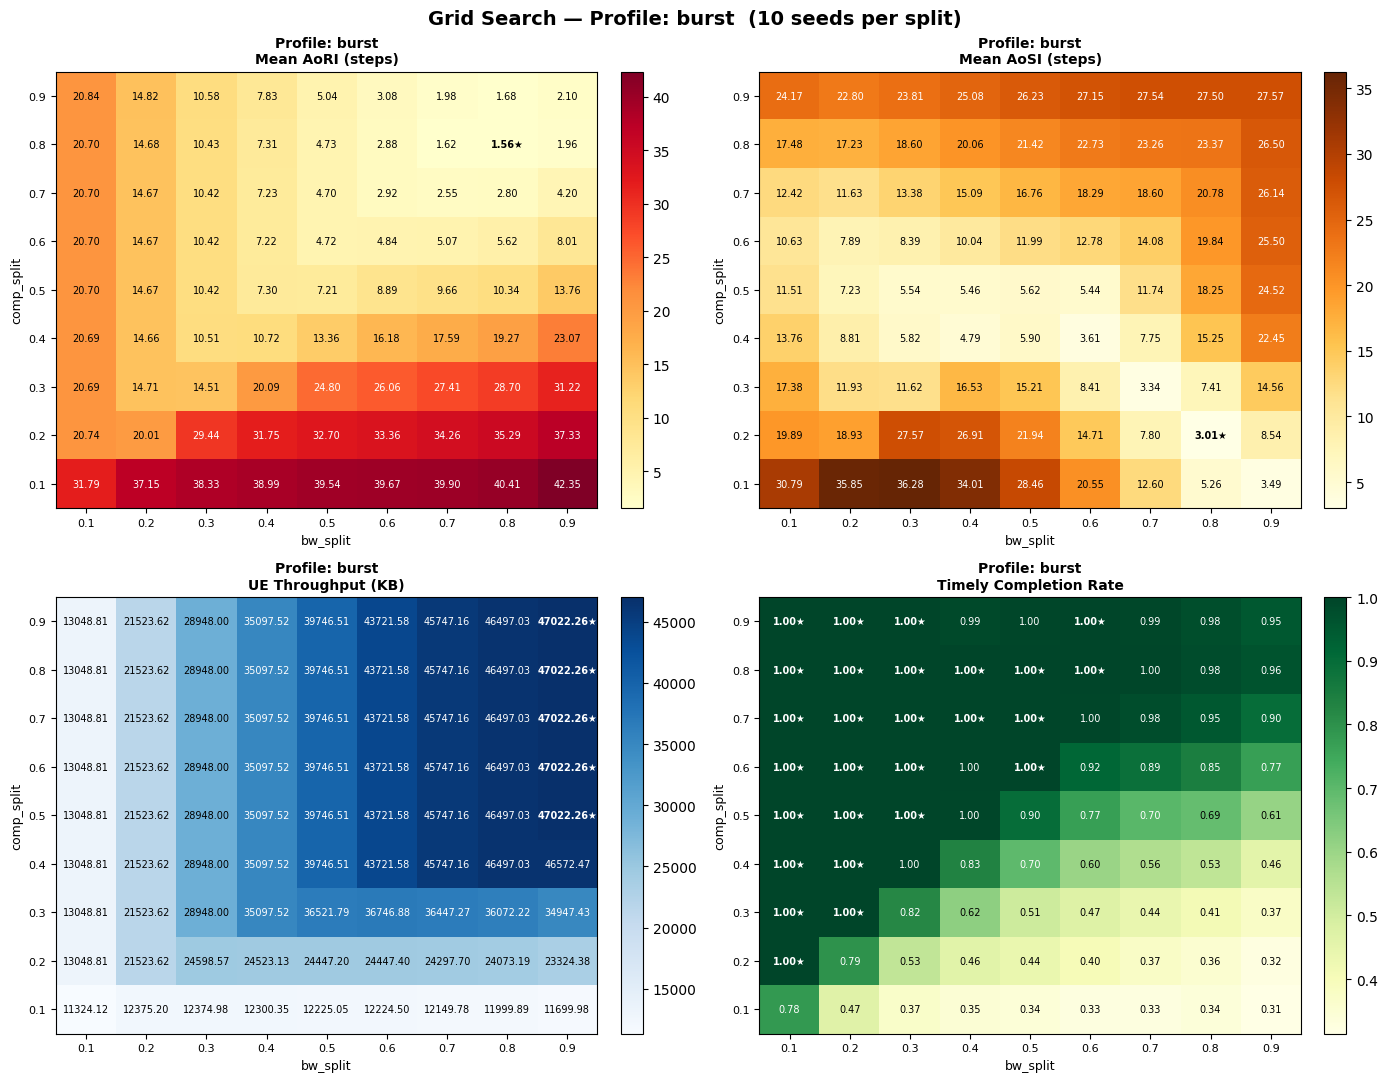

Best splits per metric:
Metric                          bw_split  comp_split       value
-----------------------------------------------------------------
Mean AoRI (steps)                    0.8         0.8       1.563
Mean AoSI (steps)                    0.8         0.2       3.006
UE Throughput (KB)                   0.9         0.5   47022.262
Completion Rate                      0.2         0.2       0.897
Timely Completion Rate               0.1         0.2       1.000
Residual Jobs at Departure           0.1         0.2       0.000


In [21]:
# ── Aggregate ─────────────────────────────────────────────────────────────
raw_df = pd.DataFrame(records)
summ = (
    raw_df.groupby(['bw_split', 'comp_split'])
    .agg(
        mean_aosi          =('mean_aosi',        'mean'),
        mean_aori          =('mean_aori',        'mean'),
        mean_throughput_kb =('ue_throughput_kb', 'mean'),
        mean_completion    =('completion_rate',  'mean'),
        mean_timely        =('timely_rate',      'mean'),
        mean_residual      =('residual_jobs',    'mean'),
    )
    .reset_index()
)

# ── Heatmaps (2x2): AoRI · AoSI · Throughput · Timely Completion Rate ───
HEATMAP_METRICS = [
    ('mean_aori',          'Mean AoRI (steps)',       'YlOrRd', np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',       'YlOrBr', np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',      'Blues',  np.nanmax),
    ('mean_timely',        'Timely Completion Rate',  'YlGn',   np.nanmax),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Grid Search — Profile: burst  (10 seeds per split)',
             fontsize=14, fontweight='bold')

for ax, (col, title, cmap, best_fn) in zip(axes.flat, HEATMAP_METRICS):
    draw_heatmap(ax, summ, col, title, cmap, best_fn, 'Profile: burst')

plt.tight_layout()
plt.show()

# ── All 6 metrics — best splits summary ──────────────────────────────────
print('Best splits per metric:')
print(f'{"Metric":<30s}  {"bw_split":>8s}  {"comp_split":>10s}  {"value":>10s}')
print('-' * 65)
for col, label, best_fn in [
    ('mean_aori',          'Mean AoRI (steps)',          np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',          np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',         np.nanmax),
    ('mean_completion',    'Completion Rate',            np.nanmax),
    ('mean_timely',        'Timely Completion Rate',     np.nanmax),
    ('mean_residual',      'Residual Jobs at Departure', np.nanmin),
]:
    valid = summ[col].dropna()
    if valid.empty:
        print(label.ljust(30) + '  ' + 'N/A')
        continue
    best_val = best_fn(valid)
    row = summ[np.isclose(summ[col], best_val)].iloc[0]
    print(f'{label:<30s}  {row.bw_split:>8.1f}  {row.comp_split:>10.1f}  {best_val:>10.3f}')

---
## Profile: `burst`

40% background UEs + 60% burst UEs arriving around step 50.

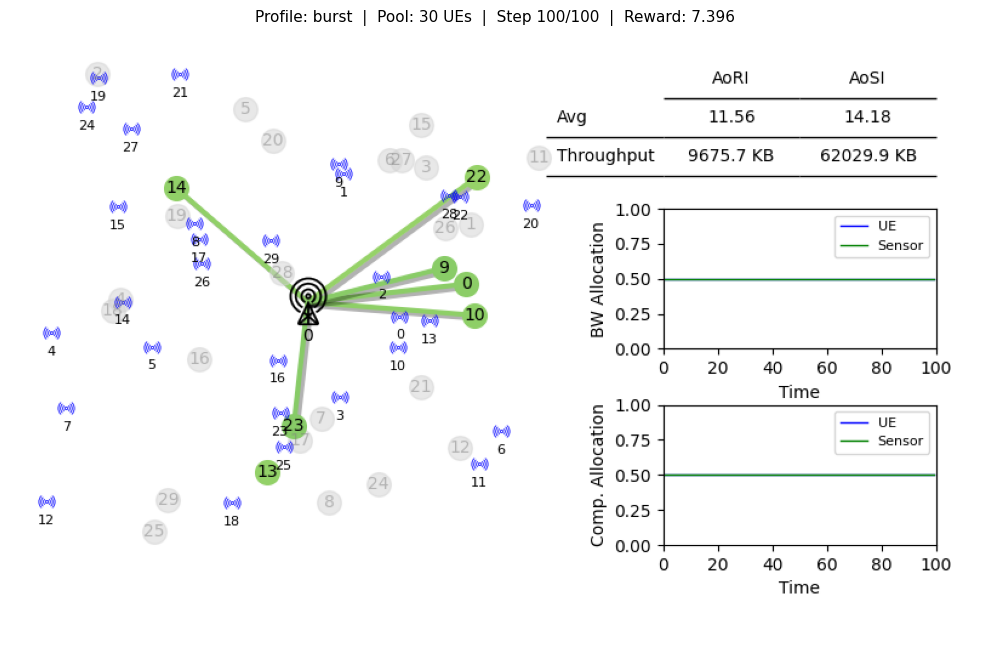

Episode complete — 100 steps  |   Total reward: 581.65


In [22]:
profile = 'burst'
n_ues  = DynamicArrival.POOL_SIZE[profile]
color  = COLORS[profile]
env    = make_env(profile)
obs, _ = env.reset()

rewards, active_ues = [], []
done = False

while not done:
    obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
    rewards.append(reward)
    active_ues.append(env.metrics.latest('num_active_ues'))
    done = terminated or truncated

    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Profile: {profile}  |  Pool: {n_ues} UEs  |  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
        fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

job_df = env.job_tracker.to_dataframe()
ue_df  = job_df[job_df['entity_type'] == 'UE']
ep     = env.metrics.finalize(env.job_tracker)
env.close()
print(f'Episode complete — {len(rewards)} steps  |   Total reward: {sum(rewards):.2f}')

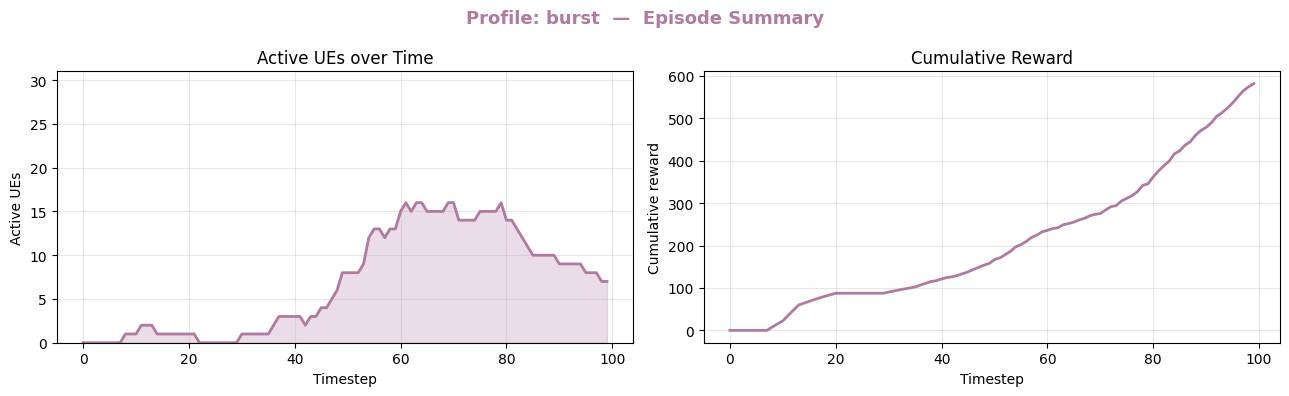

Pool            : 30 UEs
Total reward    : 581.65
UE jobs done    : 258
UE throughput   : 9.676 MB
Mean AoRI       : 11.558 steps
Mean AoSI       : 14.182 steps
Completion rate : 0.630
Timely rate     : 0.767
Residual jobs   : 9.042


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Profile: {profile}  —  Episode Summary',
             fontsize=13, fontweight='bold', color=color)

ax1.fill_between(range(len(active_ues)), active_ues, alpha=0.25, color=color)
ax1.plot(active_ues, color=color, lw=2)
ax1.set_title('Active UEs over Time')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Active UEs')
ax1.set_ylim(0, n_ues + 1)
ax1.grid(True, alpha=0.3)

ax2.plot(np.cumsum(rewards), color=color, lw=2)
ax2.set_title('Cumulative Reward')
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Cumulative reward')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

throughput_mb = ue_df['data_size'].sum() / 8e6
print(f'Pool            : {n_ues} UEs')
print(f'Total reward    : {sum(rewards):.2f}')
print(f'UE jobs done    : {len(ue_df)}')
print(f'UE throughput   : {throughput_mb:.3f} MB')
print(f'Mean AoRI       : {ep.get("mean_aori", float("nan")):.3f} steps')
print(f'Mean AoSI       : {ep.get("mean_aosi", float("nan")):.3f} steps')
print(f'Completion rate : {ep.get("job_completion_rate", float("nan")):.3f}')
print(f'Timely rate     : {ep.get("timely_completion_rate", float("nan")):.3f}')
print(f'Residual jobs   : {ep.get("mean_residual_jobs_at_departure", float("nan")):.3f}')

In [24]:
# ── Exhaustive grid search: 81 combinations x N_GRID_RUNS seeds ───────────
records = []
total   = len(GRID_SPLITS) ** 2

env = make_env(profile)   # single env, reset per run

for idx, (bw_val, comp_val) in enumerate(itertools.product(GRID_SPLITS, GRID_SPLITS), start=1):
    run_aori, run_aosi, run_jobs, run_tput = [], [], [], []

    for run in range(N_GRID_RUNS):
        obs, _ = env.reset(seed=run)
        done = False

        while not done:
            obs, r, terminated, truncated, info = env.step([bw_val, comp_val])
            done = terminated or truncated

        ep  = env.metrics.finalize(env.job_tracker)
        jdf = env.job_tracker.to_dataframe()
        udf = jdf[jdf['entity_type'] == 'UE']

        if len(udf) > 0:
            mean_aori        = udf['aori'].mean()
            mean_aosi        = udf['aosi'].mean()
            jobs_done        = len(udf)
            ue_throughput_kb = udf['data_size'].sum() / 8000
        else:
            mean_aori = mean_aosi = np.nan
            jobs_done = 0
            ue_throughput_kb = 0.0

        records.append({
            'bw_split':                bw_val,
            'comp_split':              comp_val,
            'run':                     run,
            'mean_aori':               mean_aori,
            'mean_aosi':               mean_aosi,
            'jobs_done':               jobs_done,
            'ue_throughput_kb':        ue_throughput_kb,
            'completion_rate':         ep.get('job_completion_rate', 0),
            'timely_rate':             ep.get('timely_completion_rate'),
            'residual_jobs':           ep.get('mean_residual_jobs_at_departure'),
            'mean_ue_proc_queue':      ep.get('mean_ue_proc_queue'),
            'peak_ue_proc_queue':      ep.get('peak_ue_proc_queue'),
            'final_ue_proc_queue':     ep.get('final_ue_proc_queue'),
            'mean_sensor_proc_queue':  ep.get('mean_sensor_proc_queue'),
            'peak_sensor_proc_queue':  ep.get('peak_sensor_proc_queue'),
            'final_sensor_proc_queue': ep.get('final_sensor_proc_queue'),
        })
        run_aori.append(mean_aori)
        run_aosi.append(mean_aosi)
        run_jobs.append(jobs_done)
        run_tput.append(ue_throughput_kb)

    print(
        f'  [{idx:>2}/{total}]  bw={bw_val:.1f}  comp={comp_val:.1f}'
        f'  |  AoRI={np.nanmean(run_aori):6.2f}'
        f'  AoSI={np.nanmean(run_aosi):6.2f}'
        f'  jobs={int(np.nanmean(run_jobs))}'
        f'  tput={np.nanmean(run_tput):.0f} KB'
    )

env.close()

  [ 1/81]  bw=0.1  comp=0.1  |  AoRI= 16.89  AoSI= 15.89  jobs=71  tput=2662 KB
  [ 2/81]  bw=0.1  comp=0.2  |  AoRI= 13.47  AoSI= 12.77  jobs=124  tput=4649 KB
  [ 3/81]  bw=0.1  comp=0.3  |  AoRI= 11.80  AoSI=  8.40  jobs=169  tput=6337 KB
  [ 4/81]  bw=0.1  comp=0.4  |  AoRI= 10.75  AoSI=  6.70  jobs=209  tput=7838 KB
  [ 5/81]  bw=0.1  comp=0.5  |  AoRI= 10.51  AoSI= 12.70  jobs=233  tput=8738 KB
  [ 6/81]  bw=0.1  comp=0.6  |  AoRI= 10.39  AoSI= 21.68  jobs=235  tput=8813 KB
  [ 7/81]  bw=0.1  comp=0.7  |  AoRI= 10.34  AoSI= 30.55  jobs=236  tput=8851 KB
  [ 8/81]  bw=0.1  comp=0.8  |  AoRI= 10.30  AoSI= 39.41  jobs=236  tput=8851 KB
  [ 9/81]  bw=0.1  comp=0.9  |  AoRI= 10.29  AoSI= 48.25  jobs=236  tput=8851 KB
  [10/81]  bw=0.2  comp=0.1  |  AoRI= 17.03  AoSI= 15.55  jobs=71  tput=2662 KB
  [11/81]  bw=0.2  comp=0.2  |  AoRI= 14.55  AoSI= 13.50  jobs=124  tput=4650 KB
  [12/81]  bw=0.2  comp=0.3  |  AoRI= 13.38  AoSI= 10.06  jobs=170  tput=6375 KB
  [13/81]  bw=0.2  comp=0.4  |

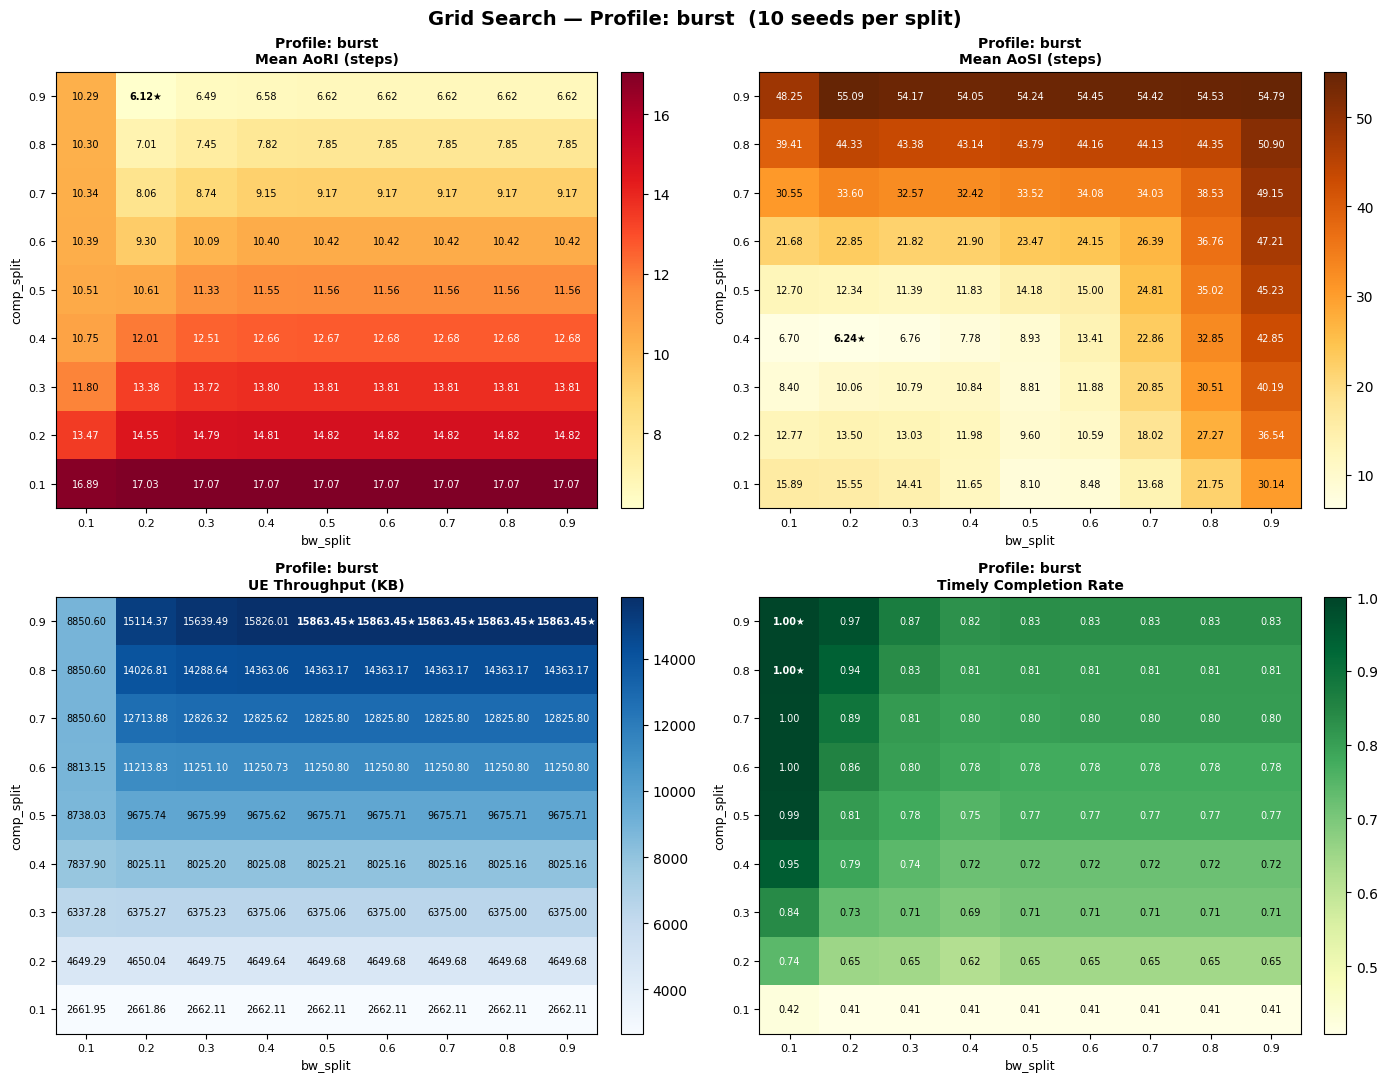

Best splits per metric:
Metric                          bw_split  comp_split       value
-----------------------------------------------------------------
Mean AoRI (steps)                    0.2         0.9       6.119
Mean AoSI (steps)                    0.2         0.4       6.238
UE Throughput (KB)                   0.5         0.9   15863.451
Completion Rate                      0.1         0.2       0.878
Timely Completion Rate               0.1         0.8       1.000
Residual Jobs at Departure           0.1         0.8       0.000


In [25]:
# ── Aggregate ─────────────────────────────────────────────────────────────
raw_df = pd.DataFrame(records)
summ = (
    raw_df.groupby(['bw_split', 'comp_split'])
    .agg(
        mean_aosi          =('mean_aosi',        'mean'),
        mean_aori          =('mean_aori',        'mean'),
        mean_throughput_kb =('ue_throughput_kb', 'mean'),
        mean_completion    =('completion_rate',  'mean'),
        mean_timely        =('timely_rate',      'mean'),
        mean_residual      =('residual_jobs',    'mean'),
    )
    .reset_index()
)

# ── Heatmaps (2x2): AoRI · AoSI · Throughput · Timely Completion Rate ───
HEATMAP_METRICS = [
    ('mean_aori',          'Mean AoRI (steps)',       'YlOrRd', np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',       'YlOrBr', np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',      'Blues',  np.nanmax),
    ('mean_timely',        'Timely Completion Rate',  'YlGn',   np.nanmax),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Grid Search — Profile: burst  (10 seeds per split)',
             fontsize=14, fontweight='bold')

for ax, (col, title, cmap, best_fn) in zip(axes.flat, HEATMAP_METRICS):
    draw_heatmap(ax, summ, col, title, cmap, best_fn, 'Profile: burst')

plt.tight_layout()
plt.show()

# ── All 6 metrics — best splits summary ──────────────────────────────────
print('Best splits per metric:')
print(f'{"Metric":<30s}  {"bw_split":>8s}  {"comp_split":>10s}  {"value":>10s}')
print('-' * 65)
for col, label, best_fn in [
    ('mean_aori',          'Mean AoRI (steps)',          np.nanmin),
    ('mean_aosi',          'Mean AoSI (steps)',          np.nanmin),
    ('mean_throughput_kb', 'UE Throughput (KB)',         np.nanmax),
    ('mean_completion',    'Completion Rate',            np.nanmax),
    ('mean_timely',        'Timely Completion Rate',     np.nanmax),
    ('mean_residual',      'Residual Jobs at Departure', np.nanmin),
]:
    valid = summ[col].dropna()
    if valid.empty:
        print(label.ljust(30) + '  ' + 'N/A')
        continue
    best_val = best_fn(valid)
    row = summ[np.isclose(summ[col], best_val)].iloc[0]
    print(f'{label:<30s}  {row.bw_split:>8.1f}  {row.comp_split:>10.1f}  {best_val:>10.3f}')